# EDL-CMSO on VeReMi NextGen — build 2, the paper's pipeline order

Rebuild of **"A Secure and Efficient Deep Learning-Based Intrusion Detection Framework
for the Internet of Vehicles"** — Khan, Tejani, AlGhamdi, Alasmari, Sharma & Sharma,
*Scientific Reports* 2025, DOI [`10.1038/s41598-025-94445-9`](https://doi.org/10.1038/s41598-025-94445-9).

**Why build 2 exists.** Build 1 ran CMSO on the 66 raw input columns, *before* the hybrid
extractor. The paper's §4.9 follows §4.8: selection happens among the features the
extractor **produces**. Build 2 restores that order, and changes nothing else that the
user controls — batch size, round count, learning rate, schedule, metric set, dataset and
CMSO population are all held at build 1's values, so the position of CMSO is the single
variable that differs between the two runs.

```
build 1   66 raw ──CMSO(41)──► DWT ─► ViT ─► GAT ─► fusion ─► DAGSNet
build 2   66 raw ─► DWT ─► ViT ─► GAT ─► fusion(Eq.28) ──CMSO──► DAGSNet
paper     identical to build 2
```

**Method (stages 3–5 of the paper).** Each row of 66 `f_*` V2X features is decomposed by a
Haar DWT into approximation and detail bands (Eq. 19), cut into 11 patches of length 6 and
linearly projected with positional encoding (Eq. 20–21), passed through a Vision
Transformer (Eq. 22–25), then through a Graph Attention Network whose adjacency is *built
from* the attention coefficients over the patch nodes (Eq. 26–27). The three
representations are fused by concatenation (Eq. 28) into `F ∈ R^{11×262}`. A CMSO
metaheuristic — the exploration phase of the Crayfish Optimization Algorithm fused with the
upbringing phase of the Mother Optimization Algorithm (Eq. 29–37) — selects a subset of
those **262 fused channels**. Classification is by **DAGSNet**: DenseNet, GoogleNet,
AlexNet and SqueezeNet branches run in parallel on the selected map, are concatenated
(Eq. 47) and fed to a fully connected softmax head (Eq. 48, 50).

**Not rebuilt, by the user's instruction:** the IoVCipherGuard crypto front end
(HE / SMPC / AES-256, §4.3–4.6), the preprocessing stage (§4.7 — the dataset already ships
imputed and standardised), and AFPHA federated aggregation (§4.6 — this build is
**centralized**, one model).

---

## The two decisions that define this build

**Eq. (28) is read literally.** `X_wavelet` is the DWT's output, so the term concatenated
is the **raw Haar coefficient patch** (length 6), not a learned projection of it. Fused
width `6 + 128 + 128 = 262`. Build 1 substituted the patch embedding, giving 384.

**CMSO runs on the extractor at initialisation.** The paper's ordering is circular — §4.8's
features come from a network that has not been trained when §4.9 is supposed to run. Of the
ways to break that, the user chose the literal one: no pretraining phase the paper does not
describe. The probe network is built under `CFG.seed`, its §4.8 parameters are frozen to
`extractor_init.pt`, CMSO searches the fused map that projection emits, and the training
worker **loads that exact state at round 0** — so the mask always refers to the projection
training actually starts from. Two consequences, both reported rather than hidden:

- the extractor then spends all 50 rounds learning to route information through the
  surviving channels, so the mask acts as a structured width reduction it adapts to;
- but at selection time those channels were random projections, so **the mask is not
  evidence about which learned features matter**. No claim of that kind is made from it.

---

## Paper vs. this notebook

| # | Paper | This notebook | Why | Kind |
|---|---|---|---|---|
| 1 | CIC-IDS 2017 / CAN / CICIoV2024 | VeReMi NextGen, 16 classes | the user's dataset | forced |
| 2 | binary normal/anomaly reporting | 16-class softmax, `C=16` | our label taxonomy; Eq. (50) permits it | forced |
| 3 | HE + SMPC + AES-256 | omitted | user instruction; affects no reported metric | user |
| 4 | median imputation (§4.7) | omitted — dataset pre-imputed with constant `0.0` *before* the split | a constant fill needs no statistic, so it cannot leak | user / forced |
| 5 | Z-score over the whole set | `train/` already standardised; `scaler.json` (train-only, `ddof=0`) applied to `test/` at load | **never** fit a statistic on test | user / forced |
| 6 | AFPHA federated aggregation | omitted — one centralized model | user decision | user |
| 7 | batch size 64 | **4096 global** (2048/GPU × 2 T4) | 64 would be 672,584 steps/epoch ≈ 187 h of T4 time against a 30 h weekly quota. Held at build 1's value | hardware / user |
| 8 | 100 epochs | **50 rounds × 1 epoch** over all 43,045,415 train rows | user set it; held at build 1's value | user |
| 9 | 1× RTX 3090 | 2× T4 DDP, fp16 AMP, `NCCL_P2P_DISABLE=1` | Kaggle hardware; Turing has no bf16/TF32 | hardware |
| 10 | LR 1e-3 "with adaptive decay", schedule unstated | 1e-3, cosine over 50 rounds, 1 warmup round | paper does not state the schedule | judgement |
| 11 | "Optimizer: CMSO" (Table 1) vs "Adam" (§4.9.2) | **Adam** trains weights; **CMSO** selects features | the paper never reconciles the two | judgement |
| 12 | DWT family/level unstated | Haar (`db1`), level 1, fixed non-learnable stride-2 conv | smallest choice satisfying Eq. (19); stays on-GPU | judgement |
| 13 | `p×p` patches over 2-D input | all 66 feats → DWT → 66 coeffs → **11 patches of length 6**, exact, no padding, **for every run** | the input is a flat tabular row. Because CMSO no longer touches the inputs, k is constant — build 1's k=1 degeneracy cannot occur | judgement |
| 14 | ViT depth/heads/`d` unstated | `d=128`, 2 layers, 4 heads, FFN ×2, dropout 0.1, pre-norm | must be small: 10,509 steps/round × 50 | judgement |
| 15 | GAT neighbourhood `N(i)` unstated | fully connected over the 11 patch nodes, 1 layer, 4 heads, LeakyReLU 0.2 | Eq. (26)'s all-pairs numerator implies it | judgement |
| **16** | Eq. (28) concatenates three tensors of different rank | **raw wavelet patch ‖ z_final ‖ z_new** on the channel axis per token → `F ∈ R^{11×262}` | Eq. (28) as printed does not type-check; this is its literal reading. **Changed from build 1**, which used the patch embedding (384) | judgement |
| 17 | backbone depths / 1-D vs 2-D unstated | four **1-D** backbones over the masked `F`, each with a 1×1 stem to 96 ch: DenseNet 3 dense layers (growth 32), GoogleNet 2 inception modules, AlexNet 3 conv+pool, SqueezeNet 3 fire modules; global-avg-pooled then concatenated | tabular rows have no 2-D structure | judgement |
| **18** | CMSO applied *after* feature extraction | **CMSO applied to the 262 fused channels of Eq. (28)** — the paper's order | **this is what build 2 changes.** The circularity is broken by selecting against the seed-frozen §4.8 projection that training then starts from | — (now matches the paper) |
| **19** | CMSO `N`,`T`,`C₁`,`μ`,`σ`, mutation, fitness all unstated | `N=20`, `T=50`, `C₁=0.2`, `μ=25`, `σ=3`, mutation 0.05; fitness = macro-F1 of a surrogate **1-D CNN** on a train-only subsample − `0.01·|S|/262` | none are given. `N` and `T` held at build 1's values so the optimiser budget stays an unchanged variable — which does mean 1000 evaluations now cover 2²⁶² instead of 2⁶⁶, and that is a stated limitation | judgement |
| 20 | Eq. (31)–(35) continuous, selection binary | sigmoid transfer + threshold 0.5, floor of 16 channels | no binarisation rule given | judgement |
| 21 | 10 binary metrics (Eq. 51–59) | the user's **10 multi-class metrics**: accuracy, P/R/F1 × {macro, micro, weighted} | the user set the metric set; specificity/NPV/MCC/FPR/FNR need a TN that 16 classes do not define without an averaging convention | user |
| 22 | pruning / quantization proposed | not applied | the paper applies them to no reported number either | judgement |
| 23 | Table 3 contrasts with/without feature selection | **one scenario: with CMSO feature selection** | user decision; the remaining quota buys one run | user |
| 24 | — | `y_prob` saved only for the best and final round; `y_pred` saved every round | 50 × 10.7 M × 16 floats would exceed Kaggle's 20 GB output cap | hardware |
| **31** | — (paper trains once, on one GPU) | the §4.8 projection CMSO selected against is **frozen to `extractor_init.pt` and reloaded at round 0** | without it the mask would describe a random projection the trained network never had. This is what makes decision A coherent rather than arbitrary | forced by A |

> **⚠ Leakage disclosure — read before quoting any per-class number.**
> **100.00%** of `trafficCongestionSybil` rows sit in a flow where *every* row is a
> first-in-session row (next highest class: `feignedBraking` 0.20%; `dosAttack` 0.00%),
> so the 16 `session` features are very close to a label for that class. **No ablation is
> run in this build** (user decision), therefore a near-perfect Sybil F1 below is
> substantially attributable to the `session` feature group, **not** to DAGSNet detecting
> Sybil behaviour, and this build cannot quantify the split. Note that build 2 makes this
> *worse*, not better: CMSO can no longer drop `session` columns at the input, because it
> no longer sees the input — every one of the 66 features reaches the extractor. Also
> state, per the dataset's own reporting requirements: the split is by **time**, not by
> vehicle; benign comes from an attack-free stream, which makes the `rate` group unusually
> strong; 3,338,358 ambiguous rows were dropped upstream; `timeDelayAttack` is the hardest
> class; imbalance is 41:1; and 88% of test flows are one message long — almost all Sybil —
> kept as-is, since DAGSNet is a per-row classifier that never assembles a flow.

**Expected cost.** k goes from build 1's 7 tokens (41 selected inputs → 42 coeffs) to a
fixed 11, and ViT/GAT/DAGSNet all scale with k, so a round should run roughly 1.4–1.6×
build 1's 701 s — call it 1000–1100 s. Fifty rounds plus CMSO plus prep is therefore
≈ 15–16 h, which exceeds the 11 h session guard and **will need two sessions**: the run
stops cleanly on the budget and resumes with its own output attached.


In [1]:
# ── Cell 2 · environment probe ───────────────────────────────────────────────
import os, sys, math, json, time, glob, shutil, platform
import numpy as np, torch

NB_T0 = time.time()          # session wall-clock origin; the round budget counts from here

print("python", platform.python_version(), "| torch", torch.__version__, "| cuda", torch.version.cuda)
n = torch.cuda.device_count(); print("GPUs:", n)
for i in range(n):
    p = torch.cuda.get_device_properties(i)
    print(f"  cuda:{i} {p.name} {p.total_memory/2**30:.1f} GB sm_{p.major}{p.minor}")
print("cpu count:", os.cpu_count())
print("RAM GB:", round(os.sysconf('SC_PAGE_SIZE') * os.sysconf('SC_PHYS_PAGES') / 2**30, 1))
for d in ("/kaggle/working", "/kaggle/temp"):
    os.makedirs(d, exist_ok=True)
    print(f"free on {d}:", round(shutil.disk_usage(d).free / 2**30, 1), "GB")

assert n == 2, f"Expected 2x T4 — got {n}. Set Accelerator to 'GPU T4 x2' and restart."
assert torch.cuda.get_device_properties(0).major == 7, \
    "Expected Turing (sm75). fp16 AMP settings below assume no bf16 and no TF32."

# proj package: %%writefile keeps the code visible in the notebook AND importable by
# the processes mp.spawn creates — functions defined in bare cells are not.
import pathlib
PKG = pathlib.Path("/kaggle/working/proj"); PKG.mkdir(parents=True, exist_ok=True)
(PKG / "__init__.py").touch()
sys.path.insert(0, "/kaggle/working")
print("proj package ready")

python 3.12.13 | torch 2.10.0+cu128 | cuda 12.8
GPUs: 2
  cuda:0 Tesla T4 14.6 GB sm_75
  cuda:1 Tesla T4 14.6 GB sm_75
cpu count: 4
RAM GB: 31.3
free on /kaggle/working: 19.5 GB
free on /kaggle/temp: 1026.8 GB
proj package ready


In [2]:
# ── Cell 3 · CFG — the single knob cell ──────────────────────────────────────
from dataclasses import dataclass, asdict, field

@dataclass
class _CFG:
    run_name: str = "edl_cmso_v2_r50_b4096"

    # ---- knobs set by the user; identical to build 1 so the ONLY variable that
    # ---- differs between the two builds is where CMSO sits in the pipeline -------
    rounds: int           = 50      # 50 rounds; checkpoints produced = 50
    epochs_per_round: int = 1       # 1 epoch per round  -> 50 epochs total
    batch_per_gpu: int    = 2048    # PER GPU. global = batch_per_gpu * 2 * grad_accum = 4096
    grad_accum: int       = 1
    # ---- paper, Table 1 -------------------------------------------------------
    lr: float             = 1e-3    # "0.001 with adaptive decay"
    weight_decay: float   = 1e-4
    warmup_rounds: int    = 1       # cosine decay after; the paper's schedule is unstated
    # ---------------------------------------------------------------------------

    # architecture (every value here fills a gap the paper leaves unstated)
    patch_len: int    = 6           # 66 = 11 x 6 exactly, no padding, k = 11 always
    d_model: int      = 128         # deviation 14
    vit_layers: int   = 2
    vit_heads: int    = 4
    vit_mlp_ratio: int= 2
    gat_heads: int    = 4           # deviation 15
    gat_slope: float  = 0.2
    dropout: float    = 0.1
    stem_ch: int      = 96          # deviation 17: 1x1 stem before each backbone
    dense_growth: int = 32
    dense_layers: int = 3
    incep_modules: int= 2
    fire_modules: int = 3

    # CMSO (deviation 19-20) — every one of these is unstated in the paper.
    # Build 2 searches the FUSED channel axis of Eq. (28): dim = patch_len + 2*d_model
    # = 262, not the 66 input columns. N and T are held at build 1's values so the
    # optimiser's own budget stays an unchanged variable between the two builds.
    cmso_enabled: bool     = True
    cmso_pop: int          = 20     # N
    cmso_iters: int        = 50     # T
    cmso_C1: float         = 0.2
    cmso_mu: float         = 25.0
    cmso_sigma: float      = 3.0
    cmso_mutation: float   = 0.05
    cmso_size_penalty: float = 0.01 # fitness = macroF1 - penalty * |S|/dim
    # 500k rows, not build 1's 2.3M: a row of F is (262 x 11) fp16 = 5.6 KB against
    # 132 B for 66 raw columns, so the resident subsample is 2.9 GB either way.
    cmso_fit_rows: int     = 400_000     # train-only subsample for the surrogate
    cmso_val_rows: int     = 100_000     # train-only holdout; NEVER the test set
    cmso_surrogate_steps: int = 400
    cmso_surrogate_batch: int = 8192

    # runtime
    # Kaggle hard-kills a batch session at 12 h. Stop cleanly before that so the final
    # cells run and the output is committed normally, then resume next session.
    max_hours: float  = 11.0
    nccl_timeout_min: int = 60      # rank 1 waits at the barrier for rank 0's full-test eval
    world_size: int   = 2
    amp: bool         = True        # fp16 — T4 has no bf16
    clip: float       = 1.0
    eval_batch: int   = 16384       # test lives on the GPU, so this is loop overhead only
    seed: int         = 42          # also pins the §4.8 projection CMSO selects against
    resume: bool      = True
    num_classes: int  = -1          # filled from meta.json
    n_features: int   = -1          # filled from meta.json — ALWAYS the full 66 in build 2
    n_selected: int   = -1          # filled by CMSO — fused channels kept, of 262
    save_prob_every: int = 0        # 0 = only best + final round (deviation 24)

CFG = _CFG()
GLOBAL_BATCH = CFG.batch_per_gpu * CFG.world_size * CFG.grad_accum
FUSED_DIM_CFG = CFG.patch_len + 2 * CFG.d_model
print(f"global batch = {CFG.batch_per_gpu} x {CFG.world_size} x {CFG.grad_accum} = {GLOBAL_BATCH}")
print(f"rounds = {CFG.rounds}  x  epochs_per_round = {CFG.epochs_per_round}"
      f"  ->  {CFG.rounds * CFG.epochs_per_round} passes over train")
print(f"Eq.(28) fused width = {CFG.patch_len} + 2 x {CFG.d_model} = {FUSED_DIM_CFG} channels"
      f"  <- this is CMSO's search space, not the 66 inputs")
print(f"session budget = {CFG.max_hours} h wall clock (Kaggle kills at 12 h)")


global batch = 2048 x 2 x 1 = 4096
rounds = 50  x  epochs_per_round = 1  ->  50 passes over train
Eq.(28) fused width = 6 + 2 x 128 = 262 channels  <- this is CMSO's search space, not the 66 inputs
session budget = 11.0 h wall clock (Kaggle kills at 12 h)


In [3]:
# ── Cell 4 · paths, run scaffold, resume probe ───────────────────────────────
from pathlib import Path

# Kaggle wipes /kaggle/working on a NEW session but commits it as output; /kaggle/temp is
# never committed. Big derived arrays go to temp (rebuilt in ~minutes); anything that must
# survive the session goes to working.
CACHE = Path("/kaggle/temp/veremi_cache"); CACHE.mkdir(parents=True, exist_ok=True)
RUNS  = Path("/kaggle/working/runs");      RUNS.mkdir(parents=True, exist_ok=True)
RUN_DIR = RUNS / CFG.run_name
for s in ("checkpoints", "metrics", "preds", "confusion", "reports", "logs"):
    (RUN_DIR / s).mkdir(parents=True, exist_ok=True)

# Say what is actually mounted BEFORE asserting: a bare "not attached" tells you nothing
# about whether the source is missing or merely nested somewhere unexpected.
print("-- /kaggle/input --")
if os.path.isdir("/kaggle/input"):
    for root, dirs, files in os.walk("/kaggle/input"):
        depth = root.count("/") - 2
        if depth > 3: dirs[:] = []; continue
        print("  " * depth + Path(root).name + "/" +
              (f"   [{len(files)} files]" if files else ""))
else:
    print("  /kaggle/input does not exist — no data source is attached at all")

# Recursive: this dataset nests the split dirs one level down (upload/train, upload/test),
# and a re-upload could nest them differently again. Match any depth, and require that the
# directory actually holds parquet so an empty namesake cannot be picked.
cands = sorted(p for p in glob.glob("/kaggle/input/**/train", recursive=True)
               if os.path.isdir(p) and glob.glob(os.path.join(p, "*.parquet")))
assert cands, ("Dataset not attached, or attached without parquet under a 'train/' dir. "
               "Add 'odixe0502/veremi-nextgen2026-centralized' via + Add Input, then re-run. "
               "The tree printed above is what the session actually sees.")
DATA = Path(cands[0]).parent
print("\ndataset root:", DATA)
for f in sorted(os.listdir(DATA)):
    p = DATA / f
    extra = f" ({len(os.listdir(p))} files)" if p.is_dir() else f" ({p.stat().st_size/2**20:.1f} MiB)"
    print("  ", f, extra)

# ---- resume probe: say plainly what is already done before anything runs ----
def probe():
    last = RUN_DIR / "checkpoints" / "last.pt"
    imported = sorted(glob.glob(f"/kaggle/input/*/runs/{CFG.run_name}/checkpoints/last.pt")) \
             + sorted(glob.glob("/kaggle/input/*/checkpoints/last.pt"))
    hist = RUN_DIR / "metrics" / "history.csv"
    print("\n-- resume probe --")
    print("  local last.pt      :", "yes" if last.exists() else "no")
    print("  attached last.pt   :", imported[0] if imported else "none")
    print("  local history.csv  :", f"{sum(1 for _ in open(hist))-1} rows" if hist.exists() else "absent")
    mask = RUN_DIR / "channel_mask.json"
    print("  CMSO channel mask  :", "cached" if mask.exists() else "not yet run")
    init = RUN_DIR / "extractor_init.pt"
    print("  §4.8 init state    :", "present" if init.exists() else "not yet frozen")
probe()

-- /kaggle/input --
input/
  datasets/
    odixe0502/
      veremi-nextgen2026-centralized/

dataset root: /kaggle/input/datasets/odixe0502/veremi-nextgen2026-centralized/upload
   README.md  (0.0 MiB)
   feature_schema.json  (0.0 MiB)
   label_mapping.json  (0.0 MiB)
   load_test.py  (0.0 MiB)
   manifest.json  (0.1 MiB)
   scaler.json  (0.0 MiB)
   statistics.json  (0.0 MiB)
   statistics.md  (0.0 MiB)
   test  (8 files)
   train  (30 files)

-- resume probe --
  local last.pt      : no
  attached last.pt   : none
  local history.csv  : absent
  CMSO channel mask  : not yet run
  §4.8 init state    : not yet frozen


## Dataset — VeReMi NextGen, 16-class centralized

Derived from Zenodo record `19665762` (DOI `10.5281/zenodo.19665762`). One row is one
received CAM message, seen from the receiving vehicle's side.

| split | files | rows | size | feature state |
|---|---:|---:|---:|---|
| `train/` | 15 | 43,045,415 | 7.3 GiB | imputed **and standardised** — use as is |
| `test/` | 4 | 10,761,343 | 1.7 GiB | imputed, **not standardised** |

**A column is a model feature if and only if its name starts with `f_`** — 66 of them,
float32, grouped as `raw` 15, `position` 4, `geometry` 20, `session` 16, `rate` 5,
`profile` 6. Everything else is leakage and is dropped: 9 identifiers (`receiver_id`,
`sender_id`, `sender_alias`, `message_id`, `rcv_time_ns`, `send_time_ns`, `orig_split`,
`source_run`, `t_rel_s`), 9 raw-context columns, plus `attack_type` and `scenario`, which
are partition columns materialised as real columns and would hand the model the answer.

**The two preprocessing steps and why the notebook skips one and applies the other.**
Imputation came *first*, before the split: every non-finite cell was filled with a constant
`0.0` while the features were one continuous stream. A constant fill needs no statistic, so
its position in the order cannot leak test into train. The 13 `zero_imputed_features` are
session deltas with no value on a session's first message — `f_first_in_session` is `1` on
exactly those rows, so the imputation stays visible to the model rather than hidden.
Standardisation came *second* and **on train only**: `mean` and `std_used` in `scaler.json`
were fitted on the 43,045,415 train rows with population variance (`ddof=0`). So `train/`
is consumed untouched, and `test/` gets that frozen transform applied at load. The cell
below asserts we never do it the other way round.

The split is by **simulation time**, with a separate cut point per (class × scenario) —
64 cut points, `rcv_time_ns < t*` to train. Nothing is split randomly, so no message leaks
from a session's future into its past. The test split is given; we do not create one.

In [4]:
# ── Cell 6 · ONE pass over parquet: audit and materialise together ───────────
import pyarrow.parquet as pq
import pandas as pd

TRAIN_DIR, TEST_DIR = DATA / "train", DATA / "test"
train_files = sorted(glob.glob(str(TRAIN_DIR / "*.parquet")))
test_files  = sorted(glob.glob(str(TEST_DIR  / "*.parquet")))
print(f"train shards: {len(train_files)}   test shards: {len(test_files)}")

schema = pq.ParquetFile(train_files[0]).schema_arrow
all_cols     = list(schema.names)
FEATURES     = [c for c in all_cols if c.startswith("f_")]     # the ONLY rule that matters
NON_FEATURES = [c for c in all_cols if not c.startswith("f_")]
print(f"\ncolumns: {len(all_cols)}   features (f_*): {len(FEATURES)}   dropped: {len(NON_FEATURES)}")
print("dropped as identifiers / labels / raw context / partition keys:")
print("  ", NON_FEATURES)

# sidecar json shipped with the dataset
def load_json(name):
    p = DATA / name
    return json.load(open(p)) if p.exists() else None
fschema, scaler_j, labmap, manifest = (load_json(f) for f in
    ("feature_schema.json", "scaler.json", "label_mapping.json", "manifest.json"))

FEATURE_GROUPS = {}
if fschema:
    declared = fschema["feature_columns"]
    assert declared == FEATURES, "feature_schema.json disagrees with the f_* rule — stop and inspect."
    print("\nfeature_schema.json agrees with the f_* rule.")
    FEATURE_GROUPS = fschema.get("groups") or fschema.get("feature_groups") or {}
    if FEATURE_GROUPS:
        print("groups:", {k: len(v) for k, v in FEATURE_GROUPS.items()})
    if "zero_imputed_features" in fschema:
        print(f"zero-imputed session features: {len(fschema['zero_imputed_features'])}")

# Frozen class axis — the index order must be identical across rounds AND sessions.
# This dataset's label_mapping.json carries three mutually redundant views:
#   label_to_class {"0": "benign", ...}   classes [ordered]   class_to_label {name: idx}
# Read the authoritative one and assert the other two agree; a disagreement means the
# class axis is not actually frozen, which silently corrupts every per-class number.
if labmap and "label_to_class" in labmap:
    inv = {int(k): v for k, v in labmap["label_to_class"].items()}
    CLASS_NAMES = [inv[i] for i in range(len(inv))]
    if "classes" in labmap:
        assert list(labmap["classes"]) == CLASS_NAMES, \
            "label_mapping.json: classes[] disagrees with label_to_class"
    if "class_to_label" in labmap:
        assert labmap["class_to_label"] == {n: i for i, n in enumerate(CLASS_NAMES)}, \
            "label_mapping.json: class_to_label is not the inverse of label_to_class"
    print("label_mapping.json: all three views agree on the class axis.")
elif labmap and all(str(k).isdigit() for k in labmap):
    inv = {int(k): v for k, v in labmap.items()}
    CLASS_NAMES = [inv[i] for i in range(len(inv))]
else:
    CLASS_NAMES = [f"class_{i}" for i in range(16)]
NUM_CLASSES = len(CLASS_NAMES)
print(f"\n{NUM_CLASSES} classes:"); [print(f"  {i:2d}  {n}") for i, n in enumerate(CLASS_NAMES)]

# scaler is fitted on TRAIN ONLY, ddof=0, and is applied to TEST ONLY
assert scaler_j is not None, "scaler.json missing — test cannot be standardised correctly."
SC = scaler_j["features"]
SC_MEAN = np.array([SC[c]["mean"]     for c in FEATURES], dtype=np.float32)
SC_STD  = np.array([SC[c]["std_used"] for c in FEATURES], dtype=np.float32)
assert (SC_STD > 0).all(), "a zero std_used would divide by zero"
print("\nscaler.json loaded: fitted on train, applied to test only (deviation 5).")

# ── the single pass ──────────────────────────────────────────────────────────
# Row counts come from the parquet FOOTERS — metadata only, nothing decoded — so the
# memmaps can be allocated before the one and only decode pass. The earlier version
# streamed every row group twice (once to audit, once to materialise); /kaggle/temp is
# wiped on every new session, so that second decode was paid again every session.
XTR = CACHE / "train_X.f16.npy"; YTR = CACHE / "train_y.i8.npy"
XTE = CACHE / "test_X.f16.npy";  YTE = CACHE / "test_y.i8.npy"
META  = CACHE / "meta.json"
AUDIT = CACHE / "audit.json"

def footer_rows(files):
    return sum(pq.ParquetFile(f).metadata.num_rows for f in files)

t_meta = time.time()
N_TRAIN, N_TEST = footer_rows(train_files), footer_rows(test_files)
print(f"\nrow counts from parquet footers in {time.time()-t_meta:.1f}s: "
      f"train {N_TRAIN:,}   test {N_TEST:,}")

def report(name, a):
    counts = np.asarray(a["counts"], dtype=np.int64); rows = a["rows"]
    print(f"\n{'='*72}\n{name}: {rows:,} rows x {len(FEATURES)} features\n{'='*72}")
    df = pd.DataFrame({"class": CLASS_NAMES, "count": counts,
                       "pct": (100 * counts / rows).round(4)})
    print(df.to_string(index=False))
    nz = counts[counts > 0]
    print(f"imbalance ratio: {counts.max() / max(nz.min(), 1):,.1f} : 1")
    print(f"empty classes  : {[CLASS_NAMES[i] for i in np.where(counts == 0)[0]] or 'none'}")
    print(f"NaN cells: {a['nan']}   Inf cells: {a['inf']}")
    assert a["nan"] == 0 and a["inf"] == 0, "dataset promises no NaN/Inf — it has some. Stop."
    print(f"feature min {a['min']:.3f}  max {a['max']:.3f}  mean(|mean|) {a['absmean']:.4f}")

def scan(files, n_rows, xp, yp, name, standardise):
    """Decode each row group ONCE: accumulate the audit and write the fp16 memmap
    from the same decoded block."""
    cache = json.loads(AUDIT.read_text()) if AUDIT.exists() else {}
    if xp.exists() and yp.exists() and xp.stem in cache:
        a = cache[xp.stem]
        print(f"\n{name}: cached from this session — parquet not re-read")
        report(name, a)
        return a["rows"], np.asarray(a["counts"], dtype=np.int64)

    X = np.lib.format.open_memmap(xp, mode="w+", dtype=np.float16, shape=(n_rows, len(FEATURES)))
    Y = np.lib.format.open_memmap(yp, mode="w+", dtype=np.int8,   shape=(n_rows,))
    counts = np.zeros(NUM_CLASSES, np.int64)
    nan_hits = inf_hits = 0
    mn = np.full(len(FEATURES),  np.inf, np.float64)
    mx = np.full(len(FEATURES), -np.inf, np.float64)
    ssum = np.zeros(len(FEATURES), np.float64)
    i = 0; t0 = time.time()
    for fp in files:
        for b in pq.ParquetFile(fp).iter_batches(batch_size=1_000_000,
                                                 columns=FEATURES + ["label"]):
            m = len(b["label"])
            A = np.column_stack([np.asarray(b[c], dtype=np.float32) for c in FEATURES])
            if standardise:                      # test only — frozen train statistics
                A = (A - SC_MEAN) / SC_STD
            yb = np.asarray(b["label"], dtype=np.int64)
            # --- audit, on the float32 block, before the fp16 cast ---
            counts += np.bincount(yb, minlength=NUM_CLASSES)
            nan_hits += int(np.isnan(A).sum()); inf_hits += int(np.isinf(A).sum())
            mn = np.minimum(mn, A.min(0)); mx = np.maximum(mx, A.max(0))
            ssum += A.sum(0, dtype=np.float64)
            # --- materialise, same block ---
            X[i:i+m] = A.astype(np.float16); Y[i:i+m] = yb.astype(np.int8)
            i += m
        print(f"    {Path(fp).name}: {i:,}/{n_rows:,}  ({time.time()-t0:.0f}s)", flush=True)
    assert i == n_rows, f"row count mismatch {i} != {n_rows}"
    X.flush(); Y.flush()
    a = {"rows": int(i), "counts": counts.tolist(), "nan": nan_hits, "inf": inf_hits,
         "min": float(mn.min()), "max": float(mx.max()),
         "absmean": float(np.abs(ssum / i).mean()), "seconds": round(time.time() - t0, 1)}
    cache[xp.stem] = a; AUDIT.write_text(json.dumps(cache, indent=2))
    report(name, a)
    print(f"one pass: decode + audit + write in {a['seconds']}s")
    return i, counts

N_TRAIN, CNT_TRAIN = scan(train_files, N_TRAIN, XTR, YTR,
                          "TRAIN (already standardised — untouched)", standardise=False)
N_TEST,  CNT_TEST  = scan(test_files,  N_TEST,  XTE, YTE,
                          "TEST  (scaler.json applied at load)",      standardise=True)

print("\n== train/test agreement ==")
te_schema = list(pq.ParquetFile(test_files[0]).schema_arrow.names)
print("cols only in train  :", sorted(set(all_cols) - set(te_schema)) or "none")
print("cols only in test   :", sorted(set(te_schema) - set(all_cols)) or "none")
print("labels only in test :", [CLASS_NAMES[i] for i in np.where((CNT_TEST > 0) & (CNT_TRAIN == 0))[0]] or "none")
print(f"train:test ratio    : {N_TRAIN/(N_TRAIN+N_TEST):.4f} : {N_TEST/(N_TRAIN+N_TEST):.4f}")


train shards: 15   test shards: 4

columns: 87   features (f_*): 66   dropped: 21
dropped as identifiers / labels / raw context / partition keys:
   ['receiver_id', 'sender_id', 'sender_alias', 'message_id', 'rcv_time_ns', 'send_time_ns', 'orig_split', 'source_run', 't_rel_s', 'label', 'rcv_pos_x', 'rcv_pos_y', 'snd_pos_x', 'snd_pos_y', 'rcv_hed', 'snd_hed', 'rcv_profile', 'snd_profile', 'snd_dist_road_edge', 'attack_type', 'scenario']

feature_schema.json agrees with the f_* rule.
groups: {'geometry': 20, 'position': 4, 'profile': 6, 'rate': 5, 'raw': 15, 'session': 16}
zero-imputed session features: 13
label_mapping.json: all three views agree on the class axis.

16 classes:
   0  benign
   1  accelerationMultiplication
   2  constantPositionOffset
   3  constantSpeedOffset
   4  dataReplay
   5  dosAttack
   6  feignedBraking
   7  positionMirroring
   8  randomPositionOffset
   9  randomSpeedOffset
  10  reversedHeading
  11  suddenConstantSpeed
  12  suddenStop
  13  timeDelayAtta

In [5]:
# ── Cell 7 · freeze meta.json (the parquet pass already wrote the memmaps) ────
# fp16 rationale: 43,045,415 x 66 is 11.4 GB in float32 but 5.7 GB in float16, and each
# rank holds only its own shard -> ~2.8 GB resident on a 16 GB T4. The data is already
# standardised (mean 0, std 1), so fp16 has ample precision for it. This is what lets the
# DataLoader disappear from the training loop entirely (see perf notes in Cell 15).
CFG.num_classes = NUM_CLASSES
CFG.n_features  = len(FEATURES)

meta = {"class_names": CLASS_NAMES, "num_classes": NUM_CLASSES,
        "feature_cols": FEATURES, "dropped_cols": NON_FEATURES,
        "n_train": int(N_TRAIN), "n_test": int(N_TEST),
        "train_counts": CNT_TRAIN.tolist(), "test_counts": CNT_TEST.tolist(),
        "scaler": {"applied_to": "test_only", "fitted_on": "train_only", "ddof": 0},
        "paths": {k: str(v) for k, v in
                  dict(train_X=XTR, train_y=YTR, test_X=XTE, test_y=YTE).items()}}
META.write_text(json.dumps(meta, indent=2))
(RUN_DIR / "meta.json").write_text(json.dumps(meta, indent=2))   # survives into the output
print(f"frozen meta.json -> {META}")
print(f"train X {XTR.stat().st_size/2**30:.2f} GB   test X {XTE.stat().st_size/2**30:.2f} GB")
print(f"free on /kaggle/temp: {shutil.disk_usage('/kaggle/temp').free/2**30:.1f} GB")

# checkpoint budget: every round is kept
print(f"\nfree on /kaggle/working: {shutil.disk_usage('/kaggle/working').free/2**30:.1f} GB "
      f"(50 checkpoints + 50 y_pred arrays must fit)")


frozen meta.json -> /kaggle/temp/veremi_cache/meta.json
train X 5.29 GB   test X 1.32 GB
free on /kaggle/temp: 1020.1 GB

free on /kaggle/working: 19.5 GB (50 checkpoints + 50 y_pred arrays must fit)


## Architecture — the paper's equations, then the code

The pipeline runs in the paper's own order, §4.8 → §4.9 → §4.10:

```
x (66 f_* features)
  │
  ├─ Eq. 19   HaarDWT           → [C_A ‖ C_D], 66 coefficients
  ├─ Eq. 20-21 PatchEmbed        → 11 patches of length 6; Linear→d=128; + E_pos
  ├─ Eq. 22-25 ViT × 2           → z_final ∈ R^{11×128}
  ├─ Eq. 26-27 GAT (all-pairs)   → z_new  ∈ R^{11×128}
  ├─ Eq. 28   Concat             → F ∈ R^{11×262}   (6 wavelet ‖ 128 ViT ‖ 128 GAT)
  │
  ├─ Eq. 29-37 CMSO channel mask → F_S ∈ R^{11×|S|}     ← §4.9 acts HERE
  │
  └─ Eq. 38-48 DAGSNet           → 16 logits
```

**Eq. (28) is read literally.** `X_wavelet` is the output of the DWT, so the term
concatenated is the **raw Haar coefficient patch** (length `patch_len = 6`), not a
learned projection of it. The fused width is therefore `6 + 128 + 128 = 262`, and a
CMSO mask over those 262 channels is directly readable: it says how many wavelet, ViT
and GAT channels survived. Build 1 substituted the patch *embedding* for this term,
which is why its fused width was 384.

**The token axis is fixed at k = 11.** All 66 input features always enter the DWT —
CMSO no longer touches the input layer — so `66 = 11 × 6` exactly, with no padding, for
every round of every run. The k=1 degeneracy that build 1 had to guard against (a GAT
softmax over a single node is the constant 1, leaving `a_src`/`a_dst` without gradient
and hanging DDP's all-reduce) cannot arise here at all.

**What the mask actually gates.** The mask is applied between fusion and the DAGSNet
stems, as `index_select` over the channel axis of the concatenation. Because `cat` and
`index_select` keep all three terms in the autograd graph, a dropped channel yields a
**zero** gradient rather than no gradient — every parameter stays "used", so
`find_unused_parameters=False` is valid for any mask. What a mask *can* do is freeze a
whole branch: keep no GAT channel and `gat.W`/`a_src`/`a_dst` sit at their random
initialisation for the entire run while still costing a forward pass every step. CMSO is
therefore floored at two channels per Eq. (28) term.


In [6]:
%%writefile /kaggle/working/proj/model.py
"""EDL-CMSO feature extractor + DAGSNet. Equation numbers refer to Khan et al. 2025.

Build 2 differs from build 1 in exactly two places, both marked below:
  * Eq. (28) concatenates the RAW wavelet patch, not its embedding  -> fused = P + 2d
  * a CMSO channel mask sits between fusion and DAGSNet             -> the paper's order
"""
import math
import torch, torch.nn as nn, torch.nn.functional as F

# Everything the CMSO probe must reproduce bit-for-bit. The mask is selected on the
# features this half of the network emits at initialisation, so training has to start
# from these exact weights or the mask refers to a projection that no longer exists.
EXTRACTOR_PREFIXES = ("dwt.", "patch.", "vit.", "vit_norm.", "gat.")


class HaarDWT(nn.Module):
    """Eq. (19). Haar (db1), level 1, as a fixed non-learnable stride-2 conv so the
    transform stays on-GPU inside the graph. Returns [C_A || C_D]."""
    def __init__(self):
        super().__init__()
        s = 1.0 / math.sqrt(2.0)
        filt = torch.tensor([[[s, s]], [[-s, s]]])          # (2,1,2): lo=approx, hi=detail
        self.register_buffer("filt", filt)

    def forward(self, x):                                    # (B, n)
        if x.shape[1] % 2:
            x = F.pad(x, (0, 1))
        y = F.conv1d(x.unsqueeze(1), self.filt, stride=2)     # (B, 2, n/2)
        return torch.cat([y[:, 0], y[:, 1]], dim=1)           # (B, n)


class PatchEmbed(nn.Module):
    """Eq. (20)-(21). k patches of length P, linear -> d, plus a learned E_pos.

    Returns (x_patch, z'). x_patch is the RAW wavelet patch and is the X_wavelet term of
    Eq. (28) read literally — build 2's decision C. Build 1 returned the projection z
    instead, making all three fusion terms d-dimensional."""
    def __init__(self, n_in, patch, d):
        super().__init__()
        self.patch = patch
        self.k = math.ceil(n_in / patch)
        self.pad = self.k * patch - n_in
        self.proj = nn.Linear(patch, d)
        self.pos = nn.Parameter(torch.zeros(1, self.k, d))
        nn.init.trunc_normal_(self.pos, std=0.02)

    def forward(self, xw):
        if self.pad:
            xw = F.pad(xw, (0, self.pad))
        xp = xw.view(xw.size(0), self.k, self.patch)              # raw C_A||C_D patches
        return xp, self.proj(xp) + self.pos                       # Eq. (20)-(21)


class ViTBlock(nn.Module):
    """Eq. (22)-(25), pre-norm. nn.MultiheadAttention is exactly Eq. (22)-(24):
    scaled dot-product over Q=z'W_Q, K=z'W_K, V=z'W_V, heads concatenated then W_O."""
    def __init__(self, d, heads, mlp_ratio, drop):
        super().__init__()
        self.n1 = nn.LayerNorm(d)
        self.att = nn.MultiheadAttention(d, heads, dropout=drop, batch_first=True)
        self.n2 = nn.LayerNorm(d)
        self.ffn = nn.Sequential(nn.Linear(d, mlp_ratio * d), nn.GELU(),
                                 nn.Dropout(drop), nn.Linear(mlp_ratio * d, d), nn.Dropout(drop))

    def forward(self, z):
        h = self.n1(z)
        z = z + self.att(h, h, h, need_weights=False)[0]      # Eq. (22)-(24)
        return z + self.ffn(self.n2(z))                        # Eq. (25)


class GATLayer(nn.Module):
    """Eq. (26)-(27). The paper never defines N(i); Eq. (26)'s numerator is all-pairs,
    so the graph is fully connected over the k patch nodes.
    a^T[W_h z_i || W_h z_j] = a_src^T W_h z_i + a_dst^T W_h z_j — two matmuls, not k^2
    concatenations."""
    def __init__(self, d_in, d_out, heads, slope, drop):
        super().__init__()
        assert d_out % heads == 0
        self.h, self.dh = heads, d_out // heads
        self.W = nn.Linear(d_in, d_out, bias=False)            # W_h
        self.a_src = nn.Parameter(torch.empty(1, heads, 1, self.dh))
        self.a_dst = nn.Parameter(torch.empty(1, heads, 1, self.dh))
        nn.init.xavier_uniform_(self.a_src); nn.init.xavier_uniform_(self.a_dst)
        self.slope = slope
        self.drop = nn.Dropout(drop)

    def forward(self, z):                                       # (B,k,d_in)
        B, k, _ = z.shape
        h = self.W(z).view(B, k, self.h, self.dh).transpose(1, 2)          # (B,H,k,dh)
        e = (h * self.a_src).sum(-1).unsqueeze(-1) \
          + (h * self.a_dst).sum(-1).unsqueeze(-2)                          # (B,H,k,k)
        alpha = self.drop(torch.softmax(F.leaky_relu(e, self.slope), dim=-1))   # Eq. (26)
        out = (alpha @ h).transpose(1, 2).reshape(B, k, -1)                 # Eq. (27)
        return F.elu(out)                                                    # sigma


# ───────────────────────── DAGSNet backbones (1-D) ─────────────────────────

def cbr(i, o, k):
    return nn.Sequential(nn.Conv1d(i, o, k, padding=k // 2, bias=False),
                         nn.BatchNorm1d(o), nn.ReLU(inplace=True))


class DenseNet1d(nn.Module):
    """Eq. (38)-(39): every layer consumes the concatenation of all preceding maps."""
    def __init__(self, cin, growth, layers):
        super().__init__()
        self.blocks = nn.ModuleList([cbr(cin + i * growth, growth, 3) for i in range(layers)])
        self.out_ch = cin + layers * growth

    def forward(self, x):
        for b in self.blocks:
            x = torch.cat([x, b(x)], dim=1)                     # Eq. (38)
        return x                                                # Eq. (39)


class Inception1d(nn.Module):
    """Eq. (40): parallel 1x1 / 3x3 / 5x5 / pool branches, concatenated."""
    def __init__(self, cin, c):
        super().__init__()
        self.b1 = cbr(cin, c, 1)
        self.b3 = nn.Sequential(cbr(cin, c, 1), cbr(c, c, 3))
        self.b5 = nn.Sequential(cbr(cin, c, 1), cbr(c, c, 5))
        self.bp = nn.Sequential(nn.MaxPool1d(3, 1, 1), cbr(cin, c, 1))
        self.out_ch = 4 * c

    def forward(self, x):
        return torch.cat([self.b1(x), self.b3(x), self.b5(x), self.bp(x)], dim=1)


class GoogleNet1d(nn.Module):
    """Eq. (40)-(41): stacked inception modules."""
    def __init__(self, cin, modules_n, c=32):
        super().__init__()
        mods, ch = [], cin
        for _ in range(modules_n):
            m = Inception1d(ch, c); mods.append(m); ch = m.out_ch
        self.net = nn.Sequential(*mods); self.out_ch = ch

    def forward(self, x):
        return self.net(x)


class AlexNet1d(nn.Module):
    """Eq. (42)-(44): conv+ReLU stack with max pooling. The token axis is only k long,
    so pooling is ceil_mode to avoid collapsing it to zero."""
    def __init__(self, cin, ch=128):
        super().__init__()
        self.net = nn.Sequential(
            cbr(cin, ch, 3), nn.MaxPool1d(2, ceil_mode=True),
            cbr(ch, ch, 3),  nn.MaxPool1d(2, ceil_mode=True),
            cbr(ch, ch, 3))
        self.out_ch = ch

    def forward(self, x):
        return self.net(x)


class Fire1d(nn.Module):
    """Eq. (45)-(46): 1x1 squeeze feeding parallel 1x1 and 3x3 expands."""
    def __init__(self, cin, sq, ex):
        super().__init__()
        self.squeeze = cbr(cin, sq, 1)                          # Eq. (46)
        self.e1 = cbr(sq, ex, 1)
        self.e3 = cbr(sq, ex, 3)
        self.out_ch = 2 * ex

    def forward(self, x):
        s = self.squeeze(x)
        return torch.cat([self.e1(s), self.e3(s)], dim=1)       # Eq. (45)


class SqueezeNet1d(nn.Module):
    def __init__(self, cin, modules_n, sq=32, ex=48):
        super().__init__()
        mods, ch = [], cin
        for _ in range(modules_n):
            m = Fire1d(ch, sq, ex); mods.append(m); ch = m.out_ch
        self.net = nn.Sequential(*mods); self.out_ch = ch

    def forward(self, x):
        return self.net(x)


class EDLCMSO(nn.Module):
    """DWT -> ViT -> GAT -> fusion (Eq. 28) -> CMSO mask (Eq. 29-37) -> DAGSNet (Eq. 47-48).

    n_features is ALWAYS the full input width (66): build 2 selects fused channels, not
    input columns, so nothing upstream of Eq. (28) ever changes shape between runs.
    sel_ch = None builds the unmasked network, which is what the CMSO probe uses."""

    def __init__(self, cfg, n_features, sel_ch=None):
        super().__init__()
        d = cfg["d_model"]
        self.dwt = HaarDWT()
        # HaarDWT pads an odd-length input to even, so the coefficient vector it returns
        # is n + (n % 2) long — not n. PatchEmbed must be sized on THAT.
        dwt_len = n_features + (n_features % 2)
        self.patch = PatchEmbed(dwt_len, cfg["patch_len"], d)
        self.vit = nn.Sequential(*[ViTBlock(d, cfg["vit_heads"], cfg["vit_mlp_ratio"], cfg["dropout"])
                                   for _ in range(cfg["vit_layers"])])
        self.vit_norm = nn.LayerNorm(d)
        self.gat = GATLayer(d, d, cfg["gat_heads"], cfg["gat_slope"], cfg["dropout"])

        # Eq. (28) read literally: raw wavelet patch || z_final || z_new.
        self.fused_dim = cfg["patch_len"] + 2 * d
        if sel_ch is None:
            sel_ch = list(range(self.fused_dim))
        sel = torch.as_tensor(sel_ch, dtype=torch.long)
        assert sel.numel() > 0 and int(sel.max()) < self.fused_dim, "channel mask out of range"
        self.register_buffer("sel_ch", sel)

        s = cfg["stem_ch"]
        self.stems = nn.ModuleList([cbr(sel.numel(), s, 1) for _ in range(4)])
        self.dense  = DenseNet1d(s, cfg["dense_growth"], cfg["dense_layers"])
        self.google = GoogleNet1d(s, cfg["incep_modules"])
        self.alex   = AlexNet1d(s)
        self.squeeze= SqueezeNet1d(s, cfg["fire_modules"])
        comb = self.dense.out_ch + self.google.out_ch + self.alex.out_ch + self.squeeze.out_ch

        self.head = nn.Sequential(                               # Eq. (48)
            nn.LayerNorm(comb), nn.Dropout(cfg["dropout"]),
            nn.Linear(comb, 256), nn.ReLU(inplace=True),
            nn.Dropout(cfg["dropout"]), nn.Linear(256, cfg["num_classes"]))

    # §4.8 in one call — this is the half CMSO sees, and the half init_state pins down.
    def fuse(self, x):
        xw = self.dwt(x)                                         # Eq. (19)
        xp, zp = self.patch(xw)                                  # Eq. (20)-(21)
        z_final = self.vit_norm(self.vit(zp))                    # Eq. (22)-(25)
        z_new = self.gat(z_final)                                # Eq. (26)-(27)
        return torch.cat([xp, z_final, z_new], dim=-1).transpose(1, 2)   # Eq. (28) (B,fused,k)

    def forward(self, x):
        Fm = self.fuse(x).index_select(1, self.sel_ch)           # §4.9 acts here
        feats = [gp(stem(Fm)) for stem, gp in
                 zip(self.stems, [self.dense, self.google, self.alex, self.squeeze])]
        pooled = [f.mean(dim=-1) for f in feats]                 # global average pool
        return self.head(torch.cat(pooled, dim=1))               # Eq. (47) -> (48)


def build_model(cfg, n_features, sel_ch=None):
    return EDLCMSO(cfg, n_features, sel_ch)


def extractor_state(model):
    """Just §4.8's parameters — the ones the CMSO mask was selected against."""
    core = getattr(model, "module", model)
    return {k: v.detach().cpu().clone() for k, v in core.state_dict().items()
            if k.startswith(EXTRACTOR_PREFIXES)}


def load_extractor_state(model, sd):
    """Restore §4.8 exactly. DAGSNet keys are expected to be missing — its width depends
    on |S|, which was not known when the probe was built."""
    core = getattr(model, "module", model)
    own = set(core.state_dict())
    unknown = [k for k in sd if k not in own]
    assert not unknown, f"extractor_init.pt has keys this model does not: {unknown[:5]}"
    missing, unexpected = core.load_state_dict(sd, strict=False)
    assert not unexpected, unexpected
    assert not [k for k in missing if k.startswith(EXTRACTOR_PREFIXES)], \
        "extractor_init.pt did not cover every §4.8 parameter"
    return len(sd)


class SurrogateCNN(nn.Module):
    """Fitness evaluator for CMSO (deviation 19). Not part of the paper's model — it is a
    miniature DAGSNet: 1-D convolutions over the same k token positions, global pool,
    linear head. Structurally analogous to the real classifier so the fitness reflects
    what DAGSNet will see, but small enough that 1000 candidate subsets cost minutes
    rather than the weeks a full-wrapper evaluation would."""
    def __init__(self, cin, n_out, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(cin, hidden, 3, padding=1, bias=False),
            nn.BatchNorm1d(hidden), nn.ReLU(inplace=True),
            nn.Conv1d(hidden, hidden, 3, padding=1, bias=False),
            nn.BatchNorm1d(hidden), nn.ReLU(inplace=True))
        self.head = nn.Linear(hidden, n_out)

    def forward(self, x):                                        # (B, cin, k)
        return self.head(self.net(x).mean(-1))


Writing /kaggle/working/proj/model.py


## Loss — categorical cross-entropy (Table 1)

With $C=16$ classes, $y_i$ the true class of sample $i$ and $p_{i,c}$ the softmax
probability the model assigns to class $c$:

$$\mathcal{L} = -\frac{1}{B}\sum_{i=1}^{B}\sum_{c=1}^{C}\mathbb{1}[y_i = c]\,\log p_{i,c}
              = -\frac{1}{B}\sum_{i=1}^{B}\log p_{i,y_i}$$

`nn.CrossEntropyLoss` applies the log-softmax internally, so the model returns raw logits
(Eq. 48 with $\sigma$ folded into the loss) — numerically the right way round under fp16 AMP.

**Unweighted, deliberately.** The paper specifies plain categorical cross-entropy and
weights nothing, and the class imbalance here is 41:1 — well inside the range where
reweighting is a modelling choice rather than a necessity. Adding class weights would be a
silent deviation that changes exactly the metric being reported (`f1_macro`), so it is not
added. `f1_macro` is where any imbalance damage will show up.

## The 10 metrics

Computed on the **entire** 10,761,343-row test set after every round, by rank 0, from a
single pass. Notation: $C=16$ classes, $N$ test samples, $n_c$ true samples of class $c$.

$$\text{Accuracy} = \frac{1}{N}\sum_{i=1}^{N}\mathbb{1}[\hat{y}_i = y_i] = \frac{\sum_c TP_c}{N}$$

Per class $P_c = \dfrac{TP_c}{TP_c + FP_c}$, $R_c = \dfrac{TP_c}{TP_c + FN_c}$, $F1_c = \dfrac{2 P_c R_c}{P_c + R_c}$.

$$P_{\text{macro}} = \frac{1}{C}\sum_c P_c \qquad P_{\text{micro}} = \frac{\sum_c TP_c}{\sum_c (TP_c + FP_c)} \qquad P_{\text{weighted}} = \sum_c \frac{n_c}{N}P_c$$

$$R_{\text{macro}} = \frac{1}{C}\sum_c R_c \qquad R_{\text{micro}} = \frac{\sum_c TP_c}{\sum_c (TP_c + FN_c)} \qquad R_{\text{weighted}} = \sum_c \frac{n_c}{N}R_c$$

$$F1_{\text{macro}} = \frac{1}{C}\sum_c F1_c \qquad F1_{\text{micro}} = \frac{2P_{\text{micro}}R_{\text{micro}}}{P_{\text{micro}} + R_{\text{micro}}} \qquad F1_{\text{weighted}} = \sum_c \frac{n_c}{N}F1_c$$

**An identity to expect, not to debug.** In single-label multi-class classification every
prediction is exactly one class, so $\sum_c FP_c = \sum_c FN_c$ and therefore

$$P_{\text{micro}} = R_{\text{micro}} = F1_{\text{micro}} = \text{Accuracy}$$

`recall_weighted` equals accuracy for the same reason. **Five of the ten columns will print
the identical number.** That is correct. The two that actually separate models on
41:1-imbalanced traffic are **`f1_macro`** (every attack class counts equally) and
**`f1_weighted`** (reliability under the real class mix).

In [7]:
%%writefile /kaggle/working/proj/metrics.py
import os, csv, json
from pathlib import Path
import numpy as np
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             confusion_matrix, classification_report)

METRIC_KEYS = ["accuracy",
               "precision_macro", "precision_micro", "precision_weighted",
               "recall_macro",    "recall_micro",    "recall_weighted",
               "f1_macro",        "f1_micro",        "f1_weighted"]


def compute_metrics(y_true, y_pred, num_classes):
    """All 10 metrics from one pass. labels=arange pins the class axis so a class the
    model never predicts still occupies its column in the macro average."""
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    labels = np.arange(num_classes)
    out = {"accuracy": float(accuracy_score(y_true, y_pred))}
    for avg in ("macro", "micro", "weighted"):
        p, r, f, _ = precision_recall_fscore_support(
            y_true, y_pred, average=avg, labels=labels, zero_division=0)
        out[f"precision_{avg}"] = float(p)
        out[f"recall_{avg}"]    = float(r)
        out[f"f1_{avg}"]        = float(f)
    return out


def atomic_write_json(path, obj):
    path = Path(path); tmp = path.with_suffix(".json.tmp")
    tmp.write_text(json.dumps(obj, indent=2)); os.replace(tmp, path)


def append_csv(path, row, columns):
    path = Path(path); new = not path.exists()
    with open(path, "a", newline="") as f:
        w = csv.DictWriter(f, fieldnames=columns, extrasaction="ignore")
        if new: w.writeheader()
        w.writerow(row)


def save_round_artifacts(round_idx, y_true, y_pred, y_prob, num_classes,
                         class_names, out_dir, extra=None, save_prob=False, metrics=None,
                         is_best=False):
    """y_pred is written every round (10.7 MB as int8). y_prob is 10.7M x 16 floats —
    344 MB per round, so 50 rounds would blow Kaggle's 20 GB output cap. It is written
    only for the best-f1_macro round and the final round (deviation 24).

    `metrics` takes an already-computed dict: the caller needs f1_macro to decide
    `save_prob`, and recomputing it here meant three more sklearn passes over 10.7M rows
    every single round."""
    out_dir = Path(out_dir); extra = extra or {}
    m = dict(metrics) if metrics is not None else compute_metrics(y_true, y_pred, num_classes)
    m["round"] = int(round_idx); m.update(extra)

    atomic_write_json(out_dir / "metrics" / f"round_{round_idx:03d}.json", m)
    append_csv(out_dir / "metrics" / "history.csv", m,
               columns=["round", *METRIC_KEYS, *extra.keys()])

    np.savez_compressed(out_dir / "preds" / f"round_{round_idx:03d}.npz",
                        y_pred=y_pred.astype(np.int8))
    if save_prob:
        # NOT savez_compressed: zlib on 344 MB of fp16 softmax costs a minute or more of
        # wall clock while rank 1 sits in the barrier.
        path = out_dir / "preds" / f"prob_round_{round_idx:03d}.npz"
        np.savez(path, y_prob=y_prob.astype(np.float16))
        # "best and final" means two files, not one per improving round. f1_macro improves
        # on most rounds early, so without this the run keeps every superseded copy —
        # 344 MB each, up to 16 GB by round 50. A new best supersedes the old one; the
        # final round is written after the last possible best, so it survives.
        if is_best:
            for old in Path(out_dir / "preds").glob("prob_round_*.npz"):
                if old != path:
                    old.unlink()
    yt = out_dir / "preds" / "y_true.npy"
    if not yt.exists():
        np.save(yt, y_true.astype(np.int8))          # identical every round — stored once

    np.save(out_dir / "confusion" / f"round_{round_idx:03d}.npy",
            confusion_matrix(y_true, y_pred, labels=np.arange(num_classes)))
    with open(out_dir / "reports" / f"round_{round_idx:03d}.txt", "w") as f:
        f.write(classification_report(y_true, y_pred, labels=np.arange(num_classes),
                                      target_names=class_names, digits=4, zero_division=0))
    return m

Writing /kaggle/working/proj/metrics.py


In [8]:
%%writefile /kaggle/working/proj/ckpt.py
"""The resume contract: kill the run at any instant, lose at most one round."""
import os, json, glob, shutil, hashlib, random
from pathlib import Path
import numpy as np, torch

SUBDIRS = ("checkpoints", "metrics", "preds", "confusion", "reports", "logs")


def run_dir(run_name):
    d = Path("/kaggle/working/runs") / run_name
    for s in SUBDIRS: (d / s).mkdir(parents=True, exist_ok=True)
    return d


def resolve_resume(run_name):
    """working/ first, then any attached input (a previous kernel's committed output).
    /kaggle/working is wiped when a NEW session starts, so cross-session resume depends
    on the dead run's output being attached as a data source."""
    d = run_dir(run_name)
    local = d / "checkpoints" / "last.pt"
    if local.exists():
        return local
    pats = [f"/kaggle/input/*/runs/{run_name}/checkpoints",
            f"/kaggle/input/*/checkpoints",
            f"/kaggle/input/*/*/runs/{run_name}/checkpoints"]
    for pat in pats:
        for src in sorted(glob.glob(pat)):
            if os.path.exists(os.path.join(src, "last.pt")):
                print(f"[resume] importing checkpoints from {src}", flush=True)
                for f in glob.glob(os.path.join(src, "*")):
                    shutil.copy2(f, d / "checkpoints")
                for sub in ("metrics", "preds", "confusion", "reports"):
                    peer = Path(src).parent / sub
                    if peer.is_dir():
                        for f in glob.glob(str(peer / "*")):
                            shutil.copy2(f, d / sub)
                # channel_mask.json and extractor_init.pt are the two files that make a
                # cross-session resume of build 2 valid: without the frozen §4.8 state the
                # resumed network would not be the one the mask was selected against.
                for side in ("channel_mask.json", "extractor_init.pt"):
                    fm = Path(src).parent / side
                    if fm.exists(): shutil.copy2(fm, d / side)
                return d / "checkpoints" / "last.pt"
    return None


def fingerprint(cfg, keys=("num_classes", "n_features", "n_selected", "batch_per_gpu",
                           "world_size", "run_name", "d_model", "patch_len")):
    """Shape-affecting config only. A changed lr may resume; a changed n_selected may not.
    n_features is in here for build 2: it is the extractor's input width, fixed at 66, and
    a checkpoint taken at another width describes a different §4.8 stack entirely."""
    payload = json.dumps({k: cfg.get(k) for k in keys}, sort_keys=True)
    return hashlib.sha256(payload.encode()).hexdigest()[:16]


def atomic_save(obj, path):
    path = Path(path); tmp = path.with_suffix(path.suffix + ".tmp")
    torch.save(obj, tmp); os.replace(tmp, path)          # os.replace is atomic on POSIX


def rng_state():
    return {"python": random.getstate(), "numpy": np.random.get_state(),
            "torch": torch.get_rng_state(),
            "cuda": torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None}


def set_rng_state(s):
    random.setstate(s["python"]); np.random.set_state(s["numpy"])
    torch.set_rng_state(s["torch"].cpu() if hasattr(s["torch"], "cpu") else s["torch"])
    if s.get("cuda") is not None: torch.cuda.set_rng_state_all(s["cuda"])


def save_round(model, opt, scaler, sched, rnd, cfg, metrics, run_name):
    d = run_dir(run_name) / "checkpoints"
    core = getattr(model, "module", model)               # unwrap DDP -> portable state
    blob = {"round": int(rnd), "model": core.state_dict(), "optim": opt.state_dict(),
            "scaler": scaler.state_dict() if scaler is not None else None,
            "sched": sched.state_dict() if sched is not None else None,
            "rng": rng_state(), "cfg": cfg,
            "fingerprint": fingerprint(cfg), "metrics": metrics}
    atomic_save(blob, d / f"ckpt_round_{rnd:03d}.pt")
    atomic_save(blob, d / "last.pt")
    return d / f"ckpt_round_{rnd:03d}.pt"


def load_for_resume(model, opt, scaler, sched, cfg, run_name, device):
    """Returns the round to start from; 0 when there is nothing to resume."""
    d = run_dir(run_name)
    last = d / "checkpoints" / "last.pt"
    if not last.exists():
        print("[resume] no checkpoint found — starting from round 0", flush=True); return 0
    ck = torch.load(last, map_location="cpu", weights_only=False)
    if ck.get("fingerprint") != fingerprint(cfg):
        raise RuntimeError(
            f"Checkpoint fingerprint {ck.get('fingerprint')} != current {fingerprint(cfg)}. "
            "A shape-affecting config changed. Rename CFG.run_name to start a new run, "
            "or restore the original config to resume this one.")
    getattr(model, "module", model).load_state_dict(ck["model"])
    opt.load_state_dict(ck["optim"])
    if scaler is not None and ck.get("scaler"): scaler.load_state_dict(ck["scaler"])
    if sched  is not None and ck.get("sched"):  sched.load_state_dict(ck["sched"])
    try: set_rng_state(ck["rng"])
    except Exception as e: print("[resume] RNG restore skipped:", e, flush=True)
    start = int(ck["round"]) + 1
    print(f"[resume] loaded round {ck['round']} -> continuing at round {start}", flush=True)
    return start

Writing /kaggle/working/proj/ckpt.py


## CMSO — feature selection on the *extracted* features (§4.9)

This is the one place build 2 departs from build 1, and it is the whole point of the
rebuild. The paper's §4.9 follows §4.8: CMSO selects among the features that the
DWT/ViT/GAT stack **produces**, not among the raw input columns. Build 1 inverted that
order (its deviation 18) because the paper's ordering is circular — §4.8's features come
from a network that has not been trained when §4.9 is supposed to run.

**The circularity is resolved the literal way, by the user's decision:** CMSO runs on the
fused map `F` emitted by the extractor **at initialisation**, before any training. The
paper's feed-forward order is then followed exactly, with no pretraining phase invented
that the paper does not describe.

**What makes that coherent rather than arbitrary.** A mask chosen against one random
projection and then applied to a *different* one would be meaningless. So the probe
network is built under `CFG.seed`, its §4.8 parameters are written to
`extractor_init.pt`, and the training worker **loads that exact state** at round 0. The
mask therefore always refers to the projection training actually starts from. The
fingerprint guard in `ckpt.py` refuses a resume if `n_selected` changed, and
`load_extractor_state` asserts every §4.8 parameter was covered.

**What this buys and what it costs.** Because the mask is fixed *before* training, the
extractor spends all 50 rounds learning to route information through the channels that
survived — it adapts to the mask rather than being pruned after the fact. What is lost is
any claim that the selected channels were *informative* at selection time: at round 0 they
were random projections, so the selection is a structured width reduction of the fusion
layer, not evidence about which learned features matter. Both halves of that go in the
report.

**Search space.** `dim` is now 262 fused channels (6 wavelet ‖ 128 ViT ‖ 128 GAT), not 66
input columns. `N` and `T` are held at build 1's values so the optimiser's own budget stays
an unchanged variable — which does mean 1000 evaluations now cover a far larger space, and
that limitation is reported rather than papered over.


In [9]:
%%writefile /kaggle/working/proj/cmso.py
"""Crayfish-Mother Swarm Optimizer, Eq. (29)-(37) of Khan et al. 2025.

Build 2 searches over the 262 FUSED channels of Eq. (28), not the 66 input columns.
Maximises fitness. Every hyperparameter here fills a gap the paper leaves unstated."""
import json, math, time
import numpy as np, torch, torch.nn as nn
from torch.amp import autocast, GradScaler
from sklearn.metrics import f1_score

from proj.model import SurrogateCNN


def _sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -60, 60)))


# Build 1 needed a floor of 2*patch_len because a small INPUT subset collapsed the token
# axis to k=1 and hung DDP. That failure mode is gone in build 2 — k is fixed at 11 — so
# this floor is only about not handing DAGSNet a degenerate one-channel feature map.
MIN_CHANNELS = 16

# ...and at least this many from EACH of Eq. (28)'s three terms.
#
# This is NOT a DDP guard. z_new reaches the loss only through F, but cat + index_select
# leave gat.W / a_src / a_dst in the autograd graph either way, so a GAT-free mask hands
# them a ZERO gradient, not None — measured, not assumed (smoke.py check 5).
# find_unused_parameters=False stays valid regardless.
#
# What a GAT-free mask would actually do is freeze the whole GAT branch at its random
# initialisation for all 50 rounds while still paying for its forward pass every step, and
# reduce Eq. (28) to a two-term concatenation. The same argument applies to the other two
# terms. Two per term keeps the fused map what the equation says it is, at a cost of at
# most 6 of 262 channels taken out of CMSO's discretion.
MIN_PER_TERM = 2


def binarise(pos, term_bounds=None, min_channels=MIN_CHANNELS, min_per_term=MIN_PER_TERM):
    """Deviation 20: S-shaped transfer + 0.5 threshold. Candidates below either floor are
    topped up by |pos| rank."""
    m = _sigmoid(pos) > 0.5
    for a, b in (term_bounds or []):
        if m[a:b].sum() < min_per_term:
            keep = a + np.argsort(-np.abs(pos[a:b]))[:min_per_term]
            m[a:b] = False
            m[keep] = True
    if m.sum() < min_channels:
        order = np.argsort(-np.abs(pos))
        extra = [i for i in order if not m[i]][:min_channels - int(m.sum())]
        m[extra] = True
    return m


class SurrogateFitness:
    """Trains a miniature DAGSNet on the masked fused map and returns macro-F1 on a
    held-out slice. Both slices are extracted from TRAIN ROWS ONLY. Results are cached by
    mask so duplicate candidates — common late in a converging swarm — cost nothing.

    Ftr/Fva are (rows, fused, k) fp16 tensors already resident on the GPU: the channel
    axis is dim 1 so a mask is a single index_select and the layout already matches
    Conv1d's (N, C, L)."""

    def __init__(self, Ftr, ytr, Fva, yva, num_classes, cfg, device):
        self.Ftr, self.ytr, self.Fva, self.yva = Ftr, ytr, Fva, yva
        self.C, self.cfg, self.device = num_classes, cfg, device
        self.cache, self.evals = {}, 0

    def __call__(self, mask):
        key = mask.tobytes()
        if key in self.cache:
            return self.cache[key]
        idx = torch.from_numpy(np.where(mask)[0]).to(self.device)
        g = torch.Generator(device=self.device); g.manual_seed(self.cfg["seed"])
        torch.manual_seed(self.cfg["seed"])

        net = SurrogateCNN(int(mask.sum()), self.C).to(self.device)
        opt = torch.optim.Adam(net.parameters(), lr=3e-3)
        scaler = GradScaler("cuda", enabled=True)
        crit = nn.CrossEntropyLoss()
        B, N = self.cfg["cmso_surrogate_batch"], self.Ftr.shape[0]

        net.train()
        for _ in range(self.cfg["cmso_surrogate_steps"]):
            sel = torch.randint(0, N, (B,), device=self.device, generator=g)
            xb = self.Ftr[sel].index_select(1, idx).float(); yb = self.ytr[sel].long()
            with autocast("cuda", dtype=torch.float16):
                loss = crit(net(xb), yb)
            opt.zero_grad(set_to_none=True)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()

        net.eval(); preds = []
        with torch.inference_mode():
            for i in range(0, self.Fva.shape[0], 32768):
                xb = self.Fva[i:i+32768].index_select(1, idx).float()
                with autocast("cuda", dtype=torch.float16):
                    preds.append(net(xb).argmax(1).cpu())
        f1 = f1_score(self.yva.cpu().numpy(), torch.cat(preds).numpy(),
                      average="macro", labels=np.arange(self.C), zero_division=0)
        fit = float(f1) - self.cfg["cmso_size_penalty"] * mask.sum() / mask.size
        self.cache[key] = fit; self.evals += 1
        del net, opt, scaler; torch.cuda.empty_cache()
        return fit


def run_cmso(fitness_fn, dim, cfg, term_bounds=None, log=print):
    """Returns (best_mask, history). Eq. (29)-(37).

    term_bounds is the list of (start, stop) spans of Eq. (28)'s three concatenated terms;
    every candidate is forced to keep MIN_PER_TERM channels from each. See binarise."""
    rng = np.random.default_rng(cfg["seed"])
    N, T = cfg["cmso_pop"], cfg["cmso_iters"]
    lb, ub = -1.0, 1.0                                   # continuous search bounds
    bina = lambda p: binarise(p, term_bounds)

    X = lb + (ub - lb) * rng.random((N, dim))            # Eq. (29)-(30)
    masks = [bina(x) for x in X]
    fit = np.array([fitness_fn(m) for m in masks])
    gi = int(np.argmax(fit))
    X_G, f_G, m_G = X[gi].copy(), fit[gi], masks[gi].copy()
    hist = []

    for t in range(1, T + 1):
        temp = rng.random() * 15 + 20                    # Eq. (31)
        C1, mu, sg = cfg["cmso_C1"], cfg["cmso_mu"], cfg["cmso_sigma"]
        p = C1 * (1.0 / (math.sqrt(2 * math.pi) * sg)) * math.exp(-((temp - mu) ** 2) / (2 * sg * sg))  # Eq. (32)
        C2 = 2 - t / T                                   # Eq. (35)
        X_L = X[int(np.argmax(fit))]                     # best of the current population

        for i in range(N):
            if temp > 30:
                # ---- summer resort, COA exploration: Eq. (33)-(34) ----
                X_shade = (X_G + X_L) / 2.0
                if rng.random() < 0.5:                   # no competitor at the cave
                    cand = X[i] + C2 * rng.random() * (X_shade - X[i])
                else:                                    # competition: move on a rival
                    j = int(rng.integers(N))
                    cand = X[i] - X[j] + X_shade
            else:
                # ---- foraging, scaled by the intake model p ----
                cand = X[i] + p * rng.normal(0, 0.3, dim) * (X_G - X[i])

            # ---- MOA upbringing, Eq. (36) ----
            cand = cand + (1 - 2 * rng.random(dim)) * (ub - lb) / t
            mut = rng.random(dim) < cfg["cmso_mutation"]
            cand[mut] = lb + (ub - lb) * rng.random(int(mut.sum()))
            cand = np.clip(cand, lb, ub)

            m = bina(cand); f = fitness_fn(m)
            if f >= fit[i]:                              # Eq. (37), sign flipped: we maximise
                X[i], fit[i] = cand, f
                if f > f_G:
                    X_G, f_G, m_G = cand.copy(), f, m.copy()

        hist.append({"iter": t, "best_fitness": float(f_G),
                     "n_selected": int(m_G.sum()), "mean_fitness": float(fit.mean()),
                     "temp": float(temp)})
        log(f"[cmso] iter {t:3d}/{T}  best {f_G:.5f}  |S| {int(m_G.sum()):3d}/{dim}  "
            f"mean {fit.mean():.5f}  temp {temp:.1f}", flush=True)
    return m_G, hist


Writing /kaggle/working/proj/cmso.py


In [10]:
# ── Cell 16 · §4.8 probe -> extract F -> §4.9 CMSO over its channels ─────────
# Order of operations, and why each step is where it is:
#   1. build the extractor under CFG.seed and FREEZE that state to extractor_init.pt
#   2. run it over a train-only subsample to get F (Eq. 28)
#   3. CMSO searches the channel axis of F
#   4. train_worker loads extractor_init.pt at round 0, so the mask and the network
#      training starts from refer to the SAME projection
# Skipping step 1 would make the whole build incoherent: the mask would describe a random
# projection that no longer exists once the model is rebuilt.
import importlib, proj.cmso as CM, proj.ckpt as C, proj.model as M
from torch.amp import autocast          # used below; every other cell gets it from proj.*
importlib.reload(CM); importlib.reload(C); importlib.reload(M)

MASK_PATH  = RUN_DIR / "channel_mask.json"
INIT_PATH  = RUN_DIR / "extractor_init.pt"
C.resolve_resume(CFG.run_name)          # may import a mask + init from an attached run

FUSED_DIM = CFG.patch_len + 2 * CFG.d_model          # Eq. (28), literal reading
dev = torch.device("cuda:0")

# ---- step 1: the frozen §4.8 projection ------------------------------------------------
if INIT_PATH.exists():
    print(f"[probe] extractor_init.pt reused ({INIT_PATH.stat().st_size/2**20:.1f} MiB)")
    probe = None
else:
    torch.manual_seed(CFG.seed); np.random.seed(CFG.seed)
    probe = M.build_model({**asdict(CFG), "num_classes": NUM_CLASSES},
                          len(FEATURES), sel_ch=None).to(dev).eval()
    torch.save(M.extractor_state(probe), INIT_PATH)
    n_ext = sum(v.numel() for v in M.extractor_state(probe).values())
    print(f"[probe] §4.8 initialised under seed {CFG.seed}: {n_ext:,} parameters frozen "
          f"to extractor_init.pt")
    print(f"[probe] k = {probe.patch.k} tokens x {CFG.patch_len} coeffs "
          f"(pad {probe.patch.pad})   fused = {probe.fused_dim} channels "
          f"= {CFG.patch_len} wavelet + {CFG.d_model} ViT + {CFG.d_model} GAT")
    assert probe.fused_dim == FUSED_DIM

# ---- steps 2-3: extract F, then search it ----------------------------------------------
if MASK_PATH.exists():
    mj = json.loads(MASK_PATH.read_text())
    SEL = np.array(mj["mask"], dtype=bool)
    print(f"[cmso] cached mask reused: {SEL.sum()}/{len(SEL)} fused channels "
          f"(fitness {mj.get('best_fitness')})")
elif not CFG.cmso_enabled:
    SEL = np.ones(FUSED_DIM, dtype=bool)
    print("[cmso] disabled — all fused channels kept")
else:
    if probe is None:                    # mask absent but init present: rebuild the probe
        torch.manual_seed(CFG.seed); np.random.seed(CFG.seed)
        probe = M.build_model({**asdict(CFG), "num_classes": NUM_CLASSES},
                              len(FEATURES), sel_ch=None).to(dev).eval()
        M.load_extractor_state(probe, torch.load(INIT_PATH, map_location=dev))
        print("[probe] rebuilt from extractor_init.pt")

    Xmm = np.load(str(XTR), mmap_mode="r"); Ymm = np.load(str(YTR), mmap_mode="r")
    rng = np.random.default_rng(CFG.seed)
    take = rng.choice(N_TRAIN, CFG.cmso_fit_rows + CFG.cmso_val_rows, replace=False)
    take.sort()                                     # sorted -> sequential memmap reads
    ys = torch.from_numpy(np.asarray(Ymm[take]).astype(np.int64)).to(dev)

    # F is (rows, 262, 11) — 8x wider per row than build 1's 66 raw columns, which is why
    # the subsample is 500k rows and not 2.3M. Extraction is one forward pass of §4.8.
    t0 = time.time()
    Fbuf = torch.empty((len(take), FUSED_DIM, probe.patch.k), dtype=torch.float16, device=dev)
    with torch.inference_mode():
        for i in range(0, len(take), 16384):
            j = min(i + 16384, len(take))
            xb = torch.from_numpy(np.asarray(Xmm[take[i:j]])).to(dev).float()
            with autocast("cuda", dtype=torch.float16):
                Fbuf[i:j] = probe.fuse(xb).to(torch.float16)
    print(f"[cmso] F extracted in {time.time()-t0:.0f}s: {tuple(Fbuf.shape)} fp16 = "
          f"{Fbuf.element_size()*Fbuf.nelement()/2**30:.2f} GB on GPU "
          f"({CFG.cmso_fit_rows:,} fit / {CFG.cmso_val_rows:,} val rows, TRAIN ONLY)")
    del probe; torch.cuda.empty_cache()

    nf = CFG.cmso_fit_rows
    fitness = CM.SurrogateFitness(Fbuf[:nf], ys[:nf], Fbuf[nf:], ys[nf:],
                                  NUM_CLASSES, asdict(CFG), dev)
    # The three Eq. (28) terms, in concatenation order. Used both as a search constraint
    # (every candidate keeps >= MIN_PER_TERM of each — see cmso.binarise) and afterwards
    # to report which term survived.
    bounds = {"wavelet": (0, CFG.patch_len),
              "vit":     (CFG.patch_len, CFG.patch_len + CFG.d_model),
              "gat":     (CFG.patch_len + CFG.d_model, FUSED_DIM)}

    t0 = time.time()
    SEL, hist = CM.run_cmso(fitness, FUSED_DIM, asdict(CFG), term_bounds=list(bounds.values()))
    print(f"[cmso] {fitness.evals} unique evaluations in {time.time()-t0:.0f}s")

    per_term = {g: int(SEL[a:b].sum()) for g, (a, b) in bounds.items()}

    MASK_PATH.write_text(json.dumps({
        "mask": SEL.tolist(), "n_selected": int(SEL.sum()), "dim": FUSED_DIM,
        "selected_per_term": per_term,
        "term_bounds": {g: list(v) for g, v in bounds.items()},
        "best_fitness": hist[-1]["best_fitness"], "history": hist,
        "note": "channels of the Eq.(28) fused map, from the seed-frozen §4.8 projection "
                "in extractor_init.pt; fitted on a train-only subsample, test never touched"},
        indent=2))
    del Fbuf, ys, fitness; torch.cuda.empty_cache()

CFG.n_selected = int(SEL.sum())
print(f"\nselected {CFG.n_selected}/{FUSED_DIM} fused channels")
mj = json.loads(MASK_PATH.read_text()) if MASK_PATH.exists() else None
if mj and "selected_per_term" in mj:
    print("\nkept per Eq. (28) term:")
    for g, n in mj["selected_per_term"].items():
        tot = mj["term_bounds"][g][1] - mj["term_bounds"][g][0]
        print(f"   {g:<8} {n:3d}/{tot:3d}")
assert CFG.n_selected >= CM.MIN_CHANNELS, "channel mask below the floor"


[probe] §4.8 initialised under seed 42: 284,164 parameters frozen to extractor_init.pt
[probe] k = 11 tokens x 6 coeffs (pad 0)   fused = 262 channels = 6 wavelet + 128 ViT + 128 GAT
[cmso] F extracted in 4s: (500000, 262, 11) fp16 = 2.68 GB on GPU (400,000 fit / 100,000 val rows, TRAIN ONLY)
[cmso] iter   1/50  best 0.55859  |S| 131/262  mean 0.54423  temp 22.1
[cmso] iter   2/50  best 0.55859  |S| 131/262  mean 0.54722  temp 30.8
[cmso] iter   3/50  best 0.55859  |S| 131/262  mean 0.54866  temp 32.8
[cmso] iter   4/50  best 0.55958  |S| 145/262  mean 0.55021  temp 34.4
[cmso] iter   5/50  best 0.55958  |S| 145/262  mean 0.55043  temp 23.7
[cmso] iter   6/50  best 0.56445  |S| 132/262  mean 0.55222  temp 21.7
[cmso] iter   7/50  best 0.56445  |S| 132/262  mean 0.55229  temp 27.8
[cmso] iter   8/50  best 0.56445  |S| 132/262  mean 0.55252  temp 21.1
[cmso] iter   9/50  best 0.56445  |S| 132/262  mean 0.55302  temp 33.6
[cmso] iter  10/50  best 0.56445  |S| 132/262  mean 0.55492  temp 3

## The DDP worker

**Round shape: epoch block.** `EPOCHS_PER_ROUND = 1`, `ROUNDS = 50`. One round is one full
pass over all 43,045,415 train rows at global batch 4096 — 10,509 optimizer steps — after
which rank 0 evaluates the **entire** 10,761,343-row test set, writes all ten metrics, and
checkpoints. The checkpoint holds the single model; there is no aggregation step, because
this build is centralized (deviation 6).

**No DataLoader in the training loop.** After CMSO the selected fused channels are ~2–3 GB in
fp16, and each rank holds only its own shard, so the whole shard lives resident on its T4.
Batching becomes an index into GPU memory: no host-to-device copies, no worker processes,
no page cache pressure. On tabular IDS data this is a larger win than AMP, and with 4 vCPU
feeding 2 T4s it is the difference between GPU-bound and CPU-starved.

Both ranks truncate to the same shard length so the step count matches — a rank that
finishes early deadlocks DDP's gradient all-reduce.

**Evaluation uses a plain sequential scan on rank 0 only.** A `DistributedSampler` pads or
drops the tail, which would silently change the score on a 10.7 M-row test set.

In [11]:
%%writefile /kaggle/working/proj/train_worker.py
import os, sys, json, time, math
from datetime import timedelta
import numpy as np, torch, torch.nn as nn, torch.distributed as dist
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.amp import autocast, GradScaler

sys.path.insert(0, "/kaggle/working")
from proj import ckpt as C
from proj.model import build_model, load_extractor_state
from proj.metrics import save_round_artifacts

TIMEOUT_MIN = 60          # overwritten from cfg in main_worker before ddp_setup runs


def ddp_setup(rank, world):
    os.environ.setdefault("MASTER_ADDR", "127.0.0.1")
    os.environ["OMP_NUM_THREADS"] = "1"
    torch.set_num_threads(1)
    # set_device BEFORE init: otherwise every rank builds its NCCL communicator on cuda:0.
    torch.cuda.set_device(rank)
    # PyTorch's NCCL default is 10 min. Rank 1 sits in the round barrier for the whole of
    # rank 0's 10.7M-row eval + artifact write; if that ever exceeds the timeout the
    # watchdog aborts the run. 60 min is generous enough to never be the cause of a kill.
    dist.init_process_group("nccl", rank=rank, world_size=world,
                            timeout=timedelta(minutes=int(TIMEOUT_MIN)))


def load_shard(path_X, path_y, rank, world, device):
    """This rank's slice of train, resident on its GPU as fp16.

    Build 2 loads ALL 66 columns: selection happens on the fused channels inside the
    model, not on the input, so nothing is dropped here. Both ranks take exactly n_per
    rows so the epoch length — and therefore the number of all_reduce calls — is
    identical; a ragged split deadlocks the first collective after the short rank ends."""
    X = np.load(path_X, mmap_mode="r"); Y = np.load(path_y, mmap_mode="r")
    n_per = X.shape[0] // world
    lo, hi = rank * n_per, (rank + 1) * n_per
    chunks_x, chunks_y = [], []
    for i in range(lo, hi, 4_000_000):                       # stream: bounded host RAM
        j = min(i + 4_000_000, hi)
        chunks_x.append(torch.from_numpy(np.asarray(X[i:j])).to(device))
        chunks_y.append(torch.from_numpy(np.asarray(Y[i:j]).astype(np.int64)).to(device))
    return torch.cat(chunks_x), torch.cat(chunks_y)


def load_test_resident(path_X, path_y, device):
    """Rank 0 keeps the whole test set on its own GPU as fp16, loaded once for the run.
    The eval loop used to fancy-index a memmap and copy host->device once per batch,
    every round, on 4 vCPU already shared with the other rank — that, not the model, was
    what made evaluation slow. 10,761,343 x 66 fp16 = 1.32 GB."""
    X = np.load(path_X, mmap_mode="r"); Y = np.load(path_y, mmap_mode="r")
    n = X.shape[0]
    chunks = []
    for i in range(0, n, 4_000_000):
        j = min(i + 4_000_000, n)
        chunks.append(torch.from_numpy(np.asarray(X[i:j])).to(device))
    return torch.cat(chunks), np.asarray(Y).astype(np.int8)


@torch.inference_mode()
def evaluate_full(model, Xte, prob_buf, cfg):
    """Rank 0 only. The ENTIRE test set, exactly once, in file order — no
    DistributedSampler, so no padded or dropped tail. Probabilities are written into a
    resident GPU buffer; they only reach the host on the rounds that are actually saved."""
    model.eval()
    n, B = Xte.shape[0], cfg["eval_batch"]
    preds = torch.empty(n, dtype=torch.int8, device=Xte.device)
    for i in range(0, n, B):
        j = min(i + B, n)
        with autocast("cuda", dtype=torch.float16, enabled=cfg["amp"]):
            logits = model(Xte[i:j].float())
        pr = torch.softmax(logits.float(), dim=1)
        prob_buf[i:j] = pr.to(torch.float16)
        preds[i:j] = pr.argmax(1).to(torch.int8)
    model.train()
    return preds.cpu().numpy()


def main_worker(rank, world, cfg):
    global TIMEOUT_MIN
    TIMEOUT_MIN = cfg.get("nccl_timeout_min", 60)
    ddp_setup(rank, world)
    device = torch.device(f"cuda:{rank}")
    is_main = rank == 0
    torch.manual_seed(cfg["seed"] + rank); np.random.seed(cfg["seed"] + rank)
    torch.backends.cudnn.benchmark = True                    # fixed input shapes

    sel_ch = np.asarray(cfg["sel_ch"], dtype=np.int64)       # FUSED channels, not columns

    Xs, Ys = load_shard(cfg["train_X"], cfg["train_y"], rank, world, device)
    if is_main:
        print(f"[rank0] shard {tuple(Xs.shape)} fp16 = "
              f"{Xs.element_size()*Xs.nelement()/2**30:.2f} GB resident", flush=True)

    model = build_model(cfg, cfg["n_features"], sel_ch.tolist()).to(device)

    # THE CONTRACT OF BUILD 2. The CMSO mask was chosen against the fused map emitted by
    # §4.8 at initialisation. Training must therefore begin from that exact projection —
    # a freshly seeded §4.8 here would leave the mask describing a network that never
    # existed. On resume the checkpoint supplies everything and this is skipped.
    if not (C.run_dir(cfg["run_name"]) / "checkpoints" / "last.pt").exists():
        sd = torch.load(cfg["init_state"], map_location="cpu")
        n = load_extractor_state(model, sd)
        if is_main:
            print(f"[rank0] §4.8 restored from extractor_init.pt ({n} tensors) — the mask "
                  f"and the network now refer to the same projection", flush=True)

    if is_main:
        print(f"[rank0] params: {sum(p.numel() for p in model.parameters()):,}   "
              f"fused {model.fused_dim} -> {len(sel_ch)} channels into DAGSNet", flush=True)
    model = DDP(model, device_ids=[rank], output_device=rank,
                gradient_as_bucket_view=True, find_unused_parameters=False)

    opt = torch.optim.AdamW(model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    scaler = GradScaler("cuda", enabled=cfg["amp"])

    # Table 1: "0.001 with adaptive decay". The schedule is unstated (deviation 10):
    # 1 warmup round, then cosine to zero across the remaining rounds.
    def lr_at(rnd):
        w = cfg["warmup_rounds"]
        if rnd < w: return (rnd + 1) / max(w, 1)
        prog = (rnd - w) / max(cfg["rounds"] - w, 1)
        return 0.5 * (1 + math.cos(math.pi * prog))
    sched = torch.optim.lr_scheduler.LambdaLR(opt, lr_at)
    crit = nn.CrossEntropyLoss()

    # rank 0 alone imports from /kaggle/input — concurrent copies race. After the barrier
    # every rank loads the identical file out of working/.
    if cfg["resume"] and is_main:
        C.resolve_resume(cfg["run_name"])
    dist.barrier()
    start_round = C.load_for_resume(model, opt, scaler, sched, cfg,
                                    cfg["run_name"], device) if cfg["resume"] else 0

    B = cfg["batch_per_gpu"]
    steps = Xs.shape[0] // B
    if is_main:
        print(f"[rank0] {steps:,} steps/epoch/rank  (global batch "
              f"{B * world * cfg['grad_accum']})", flush=True)

    # rank 0 alone evaluates, so only rank 0 pays for the resident test set
    Xte = y_true = prob_buf = None
    if is_main:
        Xte, y_true = load_test_resident(cfg["test_X"], cfg["test_y"], device)
        prob_buf = torch.empty((Xte.shape[0], cfg["num_classes"]),
                               dtype=torch.float16, device=device)
        print(f"[rank0] test {tuple(Xte.shape)} fp16 = "
              f"{Xte.element_size()*Xte.nelement()/2**30:.2f} GB resident "
              f"+ {prob_buf.element_size()*prob_buf.nelement()/2**30:.2f} GB prob buffer",
              flush=True)

    deadline = cfg.get("deadline_ts", float("inf"))
    best_f1 = -1.0
    hist_p = C.run_dir(cfg["run_name"]) / "metrics" / "history.csv"
    if hist_p.exists():
        import csv as _csv
        with open(hist_p) as f:
            best_f1 = max([float(r["f1_macro"]) for r in _csv.DictReader(f)] or [-1.0])

    for rnd in range(start_round, cfg["rounds"]):
        t0 = time.time(); model.train()
        running = torch.zeros(2, device=device)

        # ---------------- ROUND BODY: one epoch block ----------------
        for ep in range(cfg["epochs_per_round"]):
            g = torch.Generator(device=device)
            g.manual_seed(cfg["seed"] * 100003 + rnd * 1009 + ep)   # same stream on both ranks
            perm = torch.randperm(Xs.shape[0], generator=g, device=device)
            opt.zero_grad(set_to_none=True)
            for s in range(steps):
                idx = perm[s * B:(s + 1) * B]
                xb = Xs[idx].float(); yb = Ys[idx]
                with autocast("cuda", dtype=torch.float16, enabled=cfg["amp"]):
                    loss = crit(model(xb), yb) / cfg["grad_accum"]
                scaler.scale(loss).backward()
                if (s + 1) % cfg["grad_accum"] == 0:
                    scaler.unscale_(opt)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), cfg["clip"])
                    scaler.step(opt); scaler.update(); opt.zero_grad(set_to_none=True)
                running += torch.stack([loss.detach() * cfg["grad_accum"],
                                        torch.ones((), device=device)])
        sched.step()
        # -------------------------------------------------------------

        dist.all_reduce(running, op=dist.ReduceOp.SUM)
        train_loss = (running[0] / running[1]).item()

        if is_main:
            y_pred = evaluate_full(model.module, Xte, prob_buf, cfg)
            from proj.metrics import compute_metrics
            m0 = compute_metrics(y_true, y_pred, cfg["num_classes"])
            f1m = m0["f1_macro"]
            is_best = f1m > best_f1; best_f1 = max(best_f1, f1m)
            save_prob = is_best or rnd == cfg["rounds"] - 1
            y_prob = prob_buf.cpu().numpy() if save_prob else None
            m = save_round_artifacts(
                rnd, y_true, y_pred, y_prob, cfg["num_classes"], cfg["class_names"],
                C.run_dir(cfg["run_name"]), metrics=m0, is_best=is_best,
                extra={"train_loss": train_loss, "lr": opt.param_groups[0]["lr"],
                       "seconds": round(time.time() - t0, 1),
                       "samples_per_sec": round(steps * B * world * cfg["epochs_per_round"]
                                                / max(time.time() - t0, 1e-9)),
                       "peak_gb": round(torch.cuda.max_memory_allocated() / 2**30, 2)},
                save_prob=save_prob)
            C.save_round(model, opt, scaler, sched, rnd, cfg, m, cfg["run_name"])
            print(f"[round {rnd:03d}] loss {train_loss:.4f}  acc {m['accuracy']:.4f}  "
                  f"F1_mac {m['f1_macro']:.4f}  F1_wtd {m['f1_weighted']:.4f}  "
                  f"{m['seconds']}s  {m['samples_per_sec']:,}/s  peak {m['peak_gb']}GB"
                  + ("  <- best" if is_best else ""), flush=True)
            del y_pred, y_prob
            torch.cuda.reset_peak_memory_stats()

        dist.barrier()      # after the atomic write: a kill during eval leaves a valid last.pt

        # --- session budget: only begin a round we can finish -------------------
        # Both ranks must break together or the next collective deadlocks, so the
        # decision is made by all_reduce, never from each rank's own clock.
        probe = torch.tensor([time.time() - t0], device=device)
        dist.all_reduce(probe, op=dist.ReduceOp.MAX)
        round_s = probe.item()
        over = torch.tensor([1.0 if time.time() + 1.15 * round_s > deadline else 0.0],
                            device=device)
        dist.all_reduce(over, op=dist.ReduceOp.MAX)
        if over.item() > 0 and rnd + 1 < cfg["rounds"]:
            if is_main:
                left = (deadline - time.time()) / 3600
                print(f"[budget] stopping cleanly after round {rnd:03d}: next round needs "
                      f"~{round_s/60:.1f} min, {left*60:.1f} min left in the session budget. "
                      f"Re-push with this run's output attached to resume at round {rnd+1}.",
                      flush=True)
                (C.run_dir(cfg["run_name"]) / "logs" / "stopped_early.json").write_text(
                    json.dumps({"last_round": int(rnd), "next_round": int(rnd) + 1,
                                "reason": "session wall-clock budget",
                                "round_seconds": round(round_s, 1)}, indent=2))
            break

    dist.destroy_process_group()


Writing /kaggle/working/proj/train_worker.py


In [12]:
# ── Cell 19 · launch ─────────────────────────────────────────────────────────
import socket, importlib, torch.multiprocessing as mp

os.environ["NCCL_P2P_DISABLE"] = "1"        # PCIe P2P is blocked in the Kaggle container:
os.environ["NCCL_IB_DISABLE"]  = "1"        # without this init_process_group hangs until
os.environ["NCCL_ASYNC_ERROR_HANDLING"] = "1"   # the timeout instead of failing fast
os.environ["TORCH_NCCL_ASYNC_ERROR_HANDLING"] = "1"   # the name torch >= 2.2 actually reads
with socket.socket() as s:                  # free port — never hard-code 29500
    s.bind(("", 0)); os.environ["MASTER_PORT"] = str(s.getsockname()[1])

DEADLINE = NB_T0 + CFG.max_hours * 3600
print(f"prep took {(time.time()-NB_T0)/60:.1f} min; "
      f"{(DEADLINE-time.time())/3600:.2f} h of session budget left for training")

cfg = asdict(CFG)
cfg.update(deadline_ts=DEADLINE,
           class_names=CLASS_NAMES, num_classes=NUM_CLASSES,
           sel_ch=np.where(SEL)[0].tolist(), n_selected=int(SEL.sum()),
           fused_dim=FUSED_DIM, init_state=str(INIT_PATH),
           train_X=str(XTR), train_y=str(YTR), test_X=str(XTE), test_y=str(YTE))
(RUN_DIR / "config.json").write_text(json.dumps(cfg, indent=2))

# Build 2 cannot produce the k=1 GAT degeneracy build 1 guarded against — all 66 inputs
# always reach the DWT, so k is 11 for every run. What must hold instead:
assert cfg["n_features"] == len(FEATURES) == 66, \
    "the extractor must see every input column; CMSO selects fused channels, not inputs"
assert INIT_PATH.exists(), \
    "extractor_init.pt missing — the mask would refer to a projection training never sees"
assert cfg["n_selected"] >= 16, f"{cfg['n_selected']} fused channels is degenerate"
assert max(cfg["sel_ch"]) < FUSED_DIM
# Eq. (28) must arrive at DAGSNet as three terms, not one or two. A mask that keeps no
# GAT channel does not hang DDP (cat + index_select keep gat.* in the graph, so they get a
# zero gradient, not None) — it silently freezes the whole GAT branch at its random init
# for all 50 rounds while still paying its forward cost. cmso.binarise enforces the floor;
# this re-checks it because a mask can also arrive from an attached previous run.
_gat_lo = CFG.patch_len + CFG.d_model
assert SEL[_gat_lo:].sum() >= 1, "no GAT channel survived — the GAT branch would train nowhere"
assert SEL[:CFG.patch_len].sum() >= 1 and SEL[CFG.patch_len:_gat_lo].sum() >= 1, \
    "Eq. (28) must keep all three terms"

steps = (N_TRAIN // CFG.world_size) // CFG.batch_per_gpu
print(f"{steps:,} steps/epoch/rank x {CFG.world_size} ranks x {CFG.rounds} rounds")
print(f"inputs: {len(FEATURES)} (all)   fused channels: {cfg['n_selected']}/{FUSED_DIM}   "
      f"classes: {NUM_CLASSES}")
free = shutil.disk_usage('/kaggle/working').free / 2**30
print(f"free on /kaggle/working: {free:.1f} GB (50 ckpts + 50 y_pred must fit)")

import proj.train_worker as W
importlib.reload(W)                         # pick up the latest %%writefile

t0 = time.time()
try:
    mp.spawn(W.main_worker, args=(CFG.world_size, cfg), nprocs=CFG.world_size, join=True)
    stopped = RUN_DIR / "logs" / "stopped_early.json"
    done = sum(1 for _ in open(RUN_DIR / "metrics" / "history.csv")) - 1
    if stopped.exists():
        s = json.loads(stopped.read_text())
        print(f"\nstopped on the session budget after round {s['last_round']:03d} "
              f"({done}/{CFG.rounds} rounds done) in {(time.time()-t0)/3600:.2f} h.")
        print("Re-push with this kernel's output attached as a data source to resume "
              f"at round {s['next_round']}.")
    else:
        print(f"\nall {CFG.rounds} rounds complete in {(time.time()-t0)/3600:.2f} h")
except Exception:
    import traceback; traceback.print_exc()
    print("\nRun failed. A ProcessRaisedException wraps the CHILD's traceback — read the "
          "inner one. Fix the cause, re-run the %%writefile cell, then re-run this cell: "
          "training resumes from the last completed round, nothing is retrained.")
    raise


prep took 80.2 min; 9.66 h of session budget left for training
10,509 steps/epoch/rank x 2 ranks x 50 rounds
inputs: 66 (all)   fused channels: 133/262   classes: 16
free on /kaggle/working: 19.5 GB (50 ckpts + 50 y_pred must fit)


[W901 15:04:06.465639865 socket.cpp:207] [c10d] The hostname of the client socket cannot be retrieved. err=-3
[W901 15:04:06.468152949 socket.cpp:207] [c10d] The hostname of the client socket cannot be retrieved. err=-3
[W901 15:04:14.468811556 socket.cpp:207] [c10d] The hostname of the client socket cannot be retrieved. err=-3
[W901 15:04:14.490203154 Utils.hpp:137] Warning: Environment variable NCCL_ASYNC_ERROR_HANDLING is deprecated; use TORCH_NCCL_ASYNC_ERROR_HANDLING instead (function operator())
[W901 15:04:14.490203326 Utils.hpp:137] Warning: Environment variable NCCL_ASYNC_ERROR_HANDLING is deprecated; use TORCH_NCCL_ASYNC_ERROR_HANDLING instead (function operator())
/kaggle/working/proj/train_worker.py:41: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor

[rank0] shard (21522707, 66) fp16 = 2.65 GB resident
[rank0] §4.8 restored from extractor_init.pt (33 tensors) — the mask and the network now refer to the same projection
[rank0] params: 727,952   fused 262 -> 133 channels into DAGSNet


[rank0]:[W901 15:04:18.345650541 Utils.hpp:112] Warning: Environment variable NCCL_ASYNC_ERROR_HANDLING is deprecated; use TORCH_NCCL_ASYNC_ERROR_HANDLING instead (function operator())
[rank1]:[W901 15:04:18.345653443 Utils.hpp:112] Warning: Environment variable NCCL_ASYNC_ERROR_HANDLING is deprecated; use TORCH_NCCL_ASYNC_ERROR_HANDLING instead (function operator())
/usr/local/lib/python3.12/dist-packages/torch/distributed/c10d_logger.py:83: UserWarning: barrier(): using the device under current context. You can specify `device_id` in `init_process_group` to mute this warning.
  return func(*args, **kwargs)


[resume] no checkpoint found — starting from round 0
[resume] no checkpoint found — starting from round 0
[rank0] 10,509 steps/epoch/rank  (global batch 4096)
[rank0] test (10761343, 66) fp16 = 1.32 GB resident + 0.32 GB prob buffer
[round 000] loss 0.2218  acc 0.8654  F1_mac 0.8308  F1_wtd 0.8565  791.0s  54,419/s  peak 6.21GB  <- best


...

[round 043] loss nan  acc 0.2222  F1_mac 0.0227  F1_wtd 0.0808  732.2s  58,787/s  peak 5.61GB


/usr/local/lib/python3.12/dist-packages/torch/distributed/c10d_logger.py:83: UserWarning: barrier(): using the device under current context. You can specify `device_id` in `init_process_group` to mute this warning.
  return func(*args, **kwargs)


[round 044] loss nan  acc 0.2222  F1_mac 0.0227  F1_wtd 0.0808  731.7s  58,830/s  peak 5.61GB
[budget] stopping cleanly after round 044: next round needs ~12.2 min, 7.1 min left in the session budget. Re-push with this run's output attached to resume at round 45.


/usr/local/lib/python3.12/dist-packages/torch/distributed/c10d_logger.py:83: UserWarning: barrier(): using the device under current context. You can specify `device_id` in `init_process_group` to mute this warning.
  return func(*args, **kwargs)



stopped on the session budget after round 044 (45/50 rounds done) in 9.55 h.
Re-push with this kernel's output attached as a data source to resume at round 45.


45 / 50 rounds completed


,round,accuracy,precision_macro,precision_micro,precision_weighted,recall_macro,recall_micro,recall_weighted,f1_macro,f1_micro,f1_weighted
0,0,0.86545,0.85753,0.86545,0.85887,0.81582,0.86545,0.86545,0.83081,0.86545,0.85652
1,1,0.85516,0.84694,0.85516,0.84851,0.81543,0.85516,0.85516,0.82582,0.85516,0.84745
2,2,0.84320,0.82787,0.84320,0.84016,0.81950,0.84320,0.84320,0.82054,0.84320,0.83915
3,3,0.84521,0.83298,0.84521,0.84031,0.81554,0.84521,0.84521,0.81920,0.84521,0.83874
4,4,0.83937,0.82999,0.83937,0.83780,0.81796,0.83937,0.83937,0.82086,0.83937,0.83580
5,5,0.83532,0.82689,0.83532,0.83524,0.81721,0.83532,0.83532,0.81769,0.83532,0.83112
6,6,0.83819,0.82561,0.83819,0.83713,0.82190,0.83819,0.83819,0.82033,0.83819,0.83477
7,7,0.83845,0.81356,0.83845,0.83403,0.82053,0.83845,0.83845,0.81367,0.83845,0.83332
8,8,0.83799,0.82219,0.83799,0.83675,0.82127,0.83799,0.83799,0.81778,0.83799,0.83388
9,9,0.83732,0.81744,0.83732,0.83345,0.81670,0.83732,0.83732,0.81295,0.83732,0.83220



best round : 0  f1_macro 0.83081
final round: 44  f1_macro 0.02273

wall time  : 9.50 h over 45 rounds (12.7 min/round, 56,714 samples/s)

FINAL 10 METRICS (round 44)
  accuracy               0.222197
  precision_macro        0.013887
  precision_micro        0.222197
  precision_weighted     0.049371
  recall_macro           0.062500
  recall_micro           0.222197
  recall_weighted        0.222197
  f1_macro               0.022725
  f1_micro               0.222197
  f1_weighted            0.080791

Note: precision_micro = recall_micro = f1_micro = recall_weighted = accuracy.
This identity holds for any single-label multi-class problem — it is not a bug.

PER-CLASS REPORT (round 44)
                            precision    recall  f1-score   support

                    benign     0.2222    1.0000    0.3636   2391136
accelerationMultiplication     0.0000    0.0000    0.0000    157490
    constantPositionOffset     0.0000    0.0000    0.0000    442475
       constantSpeedOffset     

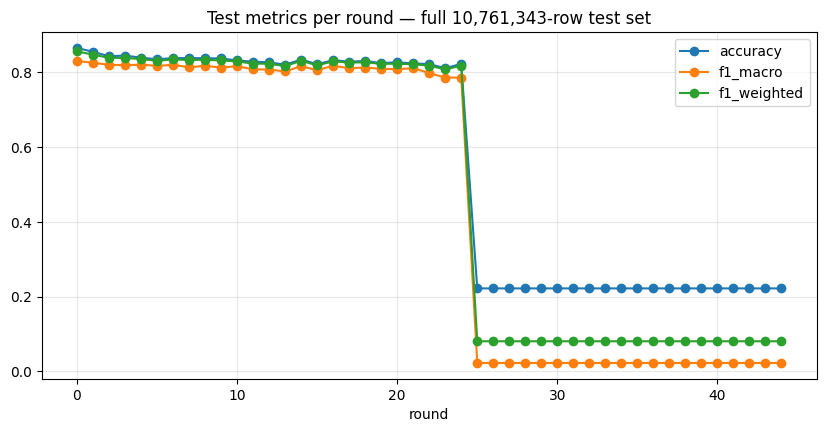

In [13]:
# ── Cell 20 · results ────────────────────────────────────────────────────────
import pandas as pd
from proj.metrics import METRIC_KEYS

hist = (pd.read_csv(RUN_DIR / "metrics" / "history.csv")
          .drop_duplicates(subset="round", keep="last")   # a re-run round appends a 2nd row
          .sort_values("round").reset_index(drop=True))
print(f"{len(hist)} / {CFG.rounds} rounds completed")
display(hist[["round", *METRIC_KEYS]].round(5))

ax = hist.plot(x="round", y=["accuracy", "f1_macro", "f1_weighted"],
               marker="o", figsize=(10, 4.5))
ax.set_title("Test metrics per round — full 10,761,343-row test set")
ax.set_xlabel("round"); ax.grid(alpha=.3)

best = hist.loc[hist["f1_macro"].idxmax()]
final = hist.iloc[-1]
print(f"\nbest round : {int(best['round'])}  f1_macro {best['f1_macro']:.5f}")
print(f"final round: {int(final['round'])}  f1_macro {final['f1_macro']:.5f}")
print(f"\nwall time  : {hist['seconds'].sum()/3600:.2f} h over {len(hist)} rounds "
      f"({hist['seconds'].mean()/60:.1f} min/round, {hist['samples_per_sec'].mean():,.0f} samples/s)")

print(f"\n{'='*72}\nFINAL 10 METRICS (round {int(final['round'])})\n{'='*72}")
for k in METRIC_KEYS:
    print(f"  {k:<22} {final[k]:.6f}")
print("\nNote: precision_micro = recall_micro = f1_micro = recall_weighted = accuracy.")
print("This identity holds for any single-label multi-class problem — it is not a bug.")

print(f"\n{'='*72}\nPER-CLASS REPORT (round {int(final['round'])})\n{'='*72}")
print(open(RUN_DIR / "reports" / f"round_{int(final['round']):03d}.txt").read())

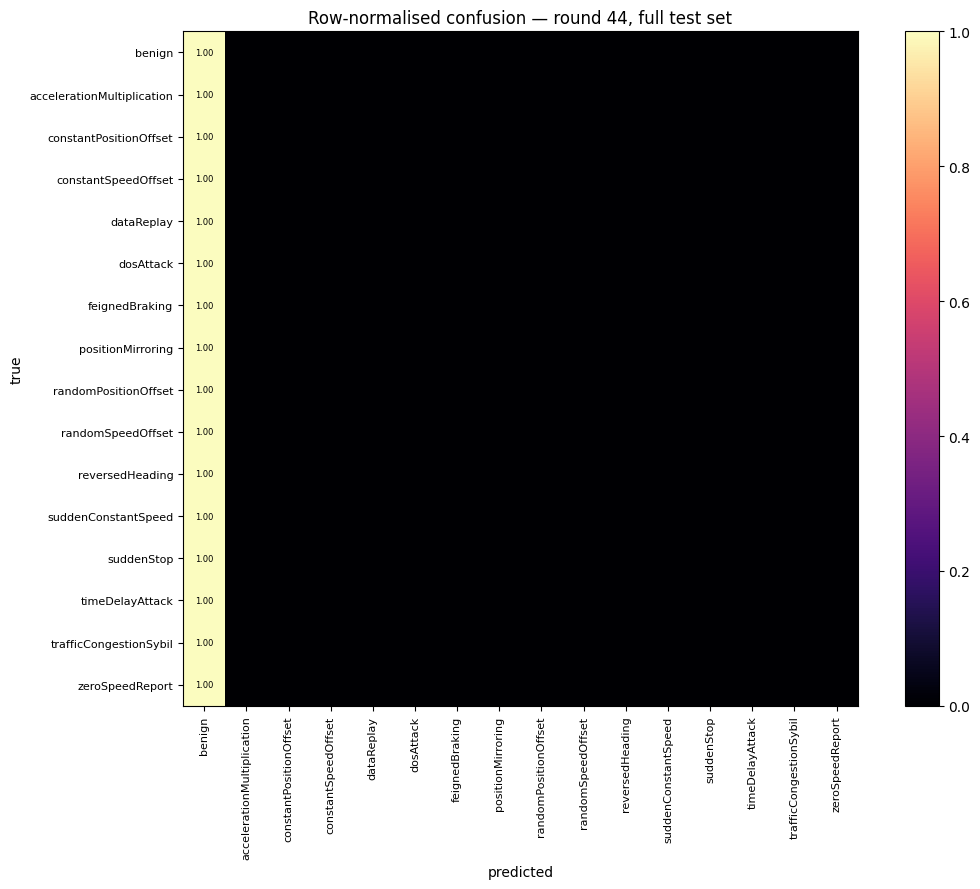

trafficCongestionSybil     precision 0.0000  recall 0.0000  f1 0.0000
timeDelayAttack            precision 0.0000  recall 0.0000  f1 0.0000


In [14]:
# ── Cell 21 · confusion matrix ───────────────────────────────────────────────
import matplotlib.pyplot as plt

cm = np.load(RUN_DIR / "confusion" / f"round_{int(final['round']):03d}.npy")
cmn = cm / np.maximum(cm.sum(1, keepdims=True), 1)

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(cmn, cmap="magma", vmin=0, vmax=1)
ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(CLASS_NAMES, rotation=90, fontsize=8)
ax.set_yticklabels(CLASS_NAMES, fontsize=8)
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title(f"Row-normalised confusion — round {int(final['round'])}, full test set")
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if cmn[i, j] > 0.005:
            ax.text(j, i, f"{cmn[i,j]:.2f}", ha="center", va="center", fontsize=6,
                    color="white" if cmn[i, j] < 0.6 else "black")
fig.colorbar(im, fraction=0.046); plt.tight_layout(); plt.show()

# the two classes the dataset card singles out
for name in ("trafficCongestionSybil", "timeDelayAttack"):
    if name in CLASS_NAMES:
        i = CLASS_NAMES.index(name)
        rec = cm[i, i] / max(cm[i].sum(), 1)
        prec = cm[i, i] / max(cm[:, i].sum(), 1)
        f1 = 2 * prec * rec / max(prec + rec, 1e-12)
        print(f"{name:<26} precision {prec:.4f}  recall {rec:.4f}  f1 {f1:.4f}")

## How to read these numbers

The ten metrics above are **16-class** on a **time-split** V2X dataset. The paper's
headline figures — Table 3 accuracy 0.99125, F-measure 0.98455; Table 4 accuracy 0.991 on
CIC-IDS 2017 — are **binary** normal/anomaly classification on different data under a
different metric convention (specificity, NPV, MCC, FPR, FNR, all of which need a TN that
16 classes do not define without an averaging choice). They are not comparable, and are
deliberately not tabulated side by side. What carries over from the paper is the *method*,
not the number.

**Against build 1.** Build 1 and build 2 share every training hyperparameter, the dataset,
the split, the metric set and the CMSO population, and differ in where CMSO sits and in the
reading of Eq. (28). A per-round comparison of `f1_macro` between the two runs is therefore
meaningful — but attribute it to *both* changes, not to the reordering alone.

**What the mask does and does not show.** CMSO selected among 262 fused channels emitted by
the §4.8 stack **at initialisation**, before any training. The count of surviving wavelet /
ViT / GAT channels printed above describes a random projection, not learned features. It is
a record of how the fusion layer was narrowed; it is **not** evidence that those channels
carry more signal. Any statement of the second kind would need the run this build does not
perform: selection against a *trained* extractor.

State all of the following with any figure quoted from this notebook:

1. The split is by **simulation time**, not by vehicle — 64 cut points, one per
   (class × scenario).
2. Benign comes from an **attack-free stream**, which makes the `rate` feature group
   unusually strong.
3. **3,338,358 ambiguous rows** (manipulated but unflagged upstream) were dropped from the
   source before this dataset existed.
4. **⚠ Sybil.** 100.00% of `trafficCongestionSybil` rows sit in a flow where every row is a
   first-in-session row, so the 16 `session` features are very nearly a label for that
   class. **No ablation was run**, and build 2 gives CMSO no way to drop them even in
   principle — selection happens after fusion, so all 66 inputs always reach the extractor.
   A high Sybil F1 above is substantially attributable to the `session` group rather than
   to DAGSNet, and this run cannot separate the two. The measurement that would is a
   50-round run with the `session` group zeroed at the input.
5. `timeDelayAttack` is the hardest class.
6. Class imbalance is **41:1** — which is why `f1_macro` is the number that matters and
   `accuracy` is close to uninformative.
7. **88% of test flows are one message long**, almost all Sybil. They are kept: DAGSNet is
   a per-row classifier that never assembles a flow, so nothing was filtered. Filtering
   short flows here would delete most of a class.
8. CMSO was fitted on a **train-only** subsample with a train-only holdout. The test set
   was never used for selection, tuning, or early stopping.

Raw `y_pred` is saved for every round and `y_prob` for the best and final rounds, so any
further metric — the paper's binary-style set included — is recomputable from
`runs/<run_name>/preds/` without retraining.
